# FinTech Innovations — Loan Approval Machine Learning Project

## CRISP-DM: Part 1 — Business Understanding and Planning

**Project:** Machine Learning for Loan Approval and Risk Assessment  
**Organization:** FinTech Innovations  
**Role:** Junior Data Scientist, Risk Analytics Team

---

### Business Problem

FinTech Innovations partners with traditional banks to modernize their loan approval processes. 
The current process relies heavily on manual review by loan officers, which can result in 
inconsistent decisions and slower responses to loan applicants.

The objective of this project is to investigate how machine learning can support a more 
consistent, efficient, data-driven loan assessment process while considering the financial 
consequences of incorrect decisions.

### Business Costs

The business has identified two important costs:

- **Missed good loan:** $8,000 average profit lost when a creditworthy applicant is denied.
- **Approved bad loan:** $50,000 average loss when a loan is approved and subsequently defaults.

Because these costs are asymmetric, model evaluation must consider more than predictive 
accuracy alone.

## 1.1 Business Context

FinTech Innovations currently relies heavily on manual loan application reviews conducted 
by loan officers. Applicants provide financial and personal information, after which loan 
officers assess the application and determine whether the loan should be approved or denied.

Although human review provides an opportunity for professional judgment, relying heavily on 
manual decisions can create several operational challenges.

### Limitations of the Current Process

1. **Inconsistent decisions**

   Different loan officers may interpret applicant information differently or place different 
   levels of importance on financial indicators.

2. **Slower processing**

   Manual assessment requires time to review financial information for each application, 
   which can increase applicant waiting times.

3. **Limited scalability**

   As application volumes increase, additional manual review capacity may be required.

4. **Potential for overlooked applicants**

   A manual process may fail to consistently identify applicants who have characteristics 
   associated with creditworthiness but do not fit conventional decision patterns.

5. **Potential for costly approval errors**

   Approving an applicant who subsequently defaults can result in a substantially larger 
   financial loss than the profit lost from rejecting a creditworthy applicant.

### Business Opportunity

A machine learning system could analyze historical applications and identify patterns 
associated with previous loan decisions or risk scores.

The intended system would not necessarily replace human decision-makers immediately. It could 
initially provide a standardized, data-driven assessment that supports loan officers and 
helps prioritize applications for review.

## 1.2 Key Stakeholders and Their Needs

A successful machine learning solution must consider the needs of multiple stakeholders.

| Stakeholder | Primary Need |
|---|---|
| Loan Officers | Consistent and interpretable information to support loan decisions |
| Risk Analytics Team | A reliable model with measurable predictive performance |
| Management | Faster processing, controlled financial losses, and operational efficiency |
| Compliance / Regulatory Teams | Transparent, explainable, and auditable decision processes |
| Credit Risk Team | Better identification of potentially risky applications |
| Applicants | Faster and more consistent loan assessments |
| Collections / Recovery Teams | Better understanding of applicants associated with higher risk |

### Stakeholder Requirements

The model therefore needs to balance several objectives:

- Predictive performance
- Interpretability
- Financial risk
- Processing efficiency
- Consistency
- Transparency
- Regulatory considerations

A technically accurate model would not be sufficient if its predictions could not be explained 
or if its errors created unacceptable financial consequences.

## 1.3 Business Impact of Model Errors

The business has identified two different financial consequences for incorrect loan decisions.

### False Positive

For this project, a false positive represents an application that the model classifies as 
approved when the appropriate outcome is denial.

This represents a potentially bad loan being approved.

**Estimated business cost: $50,000 per false positive.**

### False Negative

A false negative represents an application that the model classifies as denied when the 
appropriate outcome is approval.

This represents a potentially creditworthy applicant being rejected.

**Estimated business cost: $8,000 per false negative.**

### Asymmetric Error Costs

The two errors do not have equal financial consequences.

$$
\frac{\$50,000}{\$8,000} = 6.25
$$

Therefore, under the assumptions provided by the business, one false approval carries an 
estimated financial cost 6.25 times greater than one missed good loan.

This means that model evaluation should not rely exclusively on accuracy.

A model with high overall accuracy could still create substantial financial losses if a 
large proportion of its mistakes are costly false approvals.

### Business Cost Function

For classification, we will therefore define a custom business cost:

$$
\text{Total Error Cost}
=
(FP \times \$50,000)
+
(FN \times \$8,000)
$$

where:

- **FP** = number of false positives
- **FN** = number of false negatives

We will use this metric alongside standard machine learning evaluation metrics.

In [2]:
# import numpy for numerical operations
import numpy as np

# Business costs supplied by FinTech Innovations

FALSE_POSITIVE_COST = 50_000   # Cost of approving a bad loan
FALSE_NEGATIVE_COST = 8_000    # Cost of denying a good loan


def business_error_cost(y_true, y_pred,
                        false_positive_cost=FALSE_POSITIVE_COST,
                        false_negative_cost=FALSE_NEGATIVE_COST):
    """
    Calculate the financial cost of classification errors.

    Parameters
    ----------
    y_true : array-like
        Actual binary outcomes.

    y_pred : array-like
        Model predictions.

    false_positive_cost : float
        Financial cost associated with a false positive.

    false_negative_cost : float
        Financial cost associated with a false negative.

    Returns
    -------
    dict
        Counts and financial costs associated with model errors.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    false_positives = np.sum(
        (y_true == 0) & (y_pred == 1)
    )

    false_negatives = np.sum(
        (y_true == 1) & (y_pred == 0)
    )

    fp_cost = false_positives * false_positive_cost
    fn_cost = false_negatives * false_negative_cost

    total_cost = fp_cost + fn_cost

    return {
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "false_positive_cost": fp_cost,
        "false_negative_cost": fn_cost,
        "total_cost": total_cost
    }

## 1.4 Classification vs Regression

The business provides two possible machine learning approaches.

### Approach 1: Classification

Classification would predict a discrete loan decision, such as:

- Approved
- Denied

The model would estimate the probability of approval and then convert that probability into 
a decision using a selected threshold.

Conceptually:

**Applicant information → Classification model → Approval probability → Approval/Denial**

This approach directly addresses the business objective of supporting or automating the 
loan approval screening process.

### Approach 2: Regression

Regression would predict a continuous risk score.

Conceptually:

**Applicant information → Regression model → Risk score → Loan officer decision**

The risk score could provide more granular information to a loan officer than a simple 
approved/denied classification.

### Initial Modeling Decision

For the primary business decision problem, this project will use **classification as the 
primary modeling approach** because the stated operational problem is to improve the loan 
approval decision process.

Classification directly produces an approval/denial prediction and allows us to evaluate 
the two types of decision errors using the business-provided $8,000 and $50,000 costs.

A regression approach can also be investigated as a secondary analytical approach if the 
dataset's continuous risk score is appropriate for modeling.

However, classification will be the primary approach for evaluating the automated screening 
decision because its output maps directly to the business decision.

## 1.5 Modeling Goals

The machine learning project has five main goals.

### Goal 1 — Improve decision consistency

Develop a repeatable data-driven process that applies the same learned patterns to loan 
applications rather than relying entirely on individual manual judgments.

### Goal 2 — Identify creditworthy applicants

Reduce the number of potentially good applicants incorrectly rejected by the screening 
process.

### Goal 3 — Control costly approvals

Reduce the number of potentially bad applications incorrectly approved, recognizing that 
these errors carry an estimated $50,000 cost each.

### Goal 4 — Improve operational efficiency

Provide a model that can support loan officers by quickly assessing applications and 
identifying applications that may require further review.

### Goal 5 — Maintain interpretability

Identify the features contributing to predictions so that model outputs can be investigated, 
explained, and monitored.

## 1.6 Evaluation Metrics and Success Criteria

Because the business has asymmetric error costs, no single metric is sufficient.

We will evaluate the classification model using several complementary metrics.

### 1. Accuracy

Accuracy measures the proportion of all predictions that are correct.

$$
Accuracy =
\frac{TP + TN}{TP + TN + FP + FN}
$$

Accuracy provides an overall measure of correctness.

However, it will not be used as the only success criterion because it does not distinguish 
between a $50,000 false positive and an $8,000 false negative.

---

### 2. Precision

Precision measures the proportion of predicted approvals that are actually positive.

$$
Precision =
\frac{TP}{TP + FP}
$$

Precision is important because false approvals have the largest stated financial cost.

A low precision could indicate that many applications classified as approvals may actually 
represent costly incorrect approvals.

---

### 3. Recall

Recall measures the proportion of actual positive cases that the model successfully identifies.

$$
Recall =
\frac{TP}{TP + FN}
$$

Recall is important because a low recall means more potentially creditworthy applicants may 
be incorrectly rejected.

---

### 4. F1 Score

The F1 score combines precision and recall into a single metric.

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

F1 provides a useful balanced measure when both types of classification errors matter.

---

### 5. ROC-AUC

ROC-AUC measures the model's ability to distinguish between the two classes across different 
classification thresholds.

It is useful during model comparison because it evaluates ranking/discrimination without 
committing to a single threshold.

---

### 6. Custom Business Error Cost

The most directly business-oriented metric will be:

$$
Business\ Cost =
(FP \times \$50,000)
+
(FN \times \$8,000)
$$

This metric translates model errors into estimated financial consequences.

### Metric Strategy

The project will therefore consider:

**Primary business metric:**
- Total estimated business error cost

**Supporting classification metrics:**
- Precision
- Recall
- F1
- ROC-AUC
- Accuracy

The final model should not simply maximize one statistical metric. Its performance must be 
considered together with the financial consequences of its errors.

## 1.7 Baseline Performance

Before evaluating machine learning models, we need simple baselines.

A baseline provides a reference point against which the machine learning model can be 
compared.

### Baseline 1 — Majority-Class Model

The simplest classification baseline will predict the most common class for every applicant.

For example, if 70% of historical applications belong to one class, the baseline would 
predict that class for every application.

Its accuracy would therefore be approximately the proportion of the majority class.

The machine learning model should demonstrate useful predictive performance beyond this 
simple strategy.

### Baseline 2 — Reject-All Policy

We will evaluate the financial consequences of rejecting every application.

This policy produces:

- No false approvals
- Potentially many missed good loans

Its business cost is therefore primarily associated with false negatives.

### Baseline 3 — Approve-All Policy

We will also evaluate approving every application.

This policy produces:

- No false negatives
- Potentially many false approvals

Because false approvals cost $50,000 each, this provides an important financial benchmark.

### Baseline Success Requirement

The final model should demonstrate meaningful improvement over the relevant baseline in both:

1. Predictive performance
2. Estimated business error cost

We will calculate these baselines after loading and inspecting the actual dataset.

In [3]:
def evaluate_business_policy(y_true, y_pred, policy_name):
    """
    Evaluate a classification policy using the business cost structure.
    """

    results = business_error_cost(y_true, y_pred)

    return {
        "Policy": policy_name,
        "False Positives": results["false_positives"],
        "False Negatives": results["false_negatives"],
        "FP Cost ($)": results["false_positive_cost"],
        "FN Cost ($)": results["false_negative_cost"],
        "Total Error Cost ($)": results["total_cost"],
        "Cost per Application ($)": (
            results["total_cost"] / len(y_true)
        )
    }

# 2. Data Understanding and Exploration

This phase examines the structure, quality, distributions, and relationships within the 
loan datasets before model development.

The analysis will:

- Compare the two supplied datasets.
- Examine their structure and data quality.
- Understand numerical, categorical, and ordinal features.
- Investigate target distributions.
- Explore relationships between important variables.
- Identify missing values, outliers, and potential data issues.
- Identify opportunities for feature engineering.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

sns.set_theme(style="whitegrid")

np.random.seed(42)

## 2.1 Load the Datasets

Two versions of the loan dataset are provided:

- The **financial loan dataset** contains intentionally messy data that requires cleaning.
- The **Loan dataset** is the reference version and contains `ApplicationDate` plus cleaner 
  representations of several variables.

Both datasets contain 20,000 applications. They will first be inspected separately before 
any data preparation or reconciliation is performed.

In [5]:
# Load the two datasets

messy = pd.read_csv("financial_loan_data.csv")
reference = pd.read_csv("Loan.csv")

print("Messy dataset shape:", messy.shape)
print("Reference dataset shape:", reference.shape)

Messy dataset shape: (20000, 35)
Reference dataset shape: (20000, 36)


In [6]:
display(messy.head())
display(reference.head())

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354,1,2,0.358,No,Home,0,29,9,"7,632.000",1202,146111,19183,"3,329.000",0.725,11,126928,0.200,0.228,419.806,0.181,0,49.000
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.088,5,3,0.330,No,Debt Consolidation,0,21,9,"4,627.000",3460,53204,9595,"3,309.083",0.935,3,43609,0.207,0.201,794.054,0.390,0,52.000
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137,2,0,0.245,No,Education,0,20,22,886.000,895,25176,128874,"3,393.667",0.872,6,5205,0.218,0.213,666.407,0.462,0,52.000
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.268,2,1,0.436,No,Home,0,27,10,"1,675.000",1217,104822,5370,"5,757.000",0.896,5,99452,0.300,0.301,"1,047.507",0.313,0,54.000
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.321,0,0,0.079,No,Debt Consolidation,0,26,27,"1,555.000",4981,244305,17286,"8,605.333",0.941,5,227019,0.197,0.176,330.179,0.070,1,36.000


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354,1,2,0.358,0,Home,0,29,9,7632,1202,146111,19183,"3,329.000",0.725,11,126928,0.200,0.228,419.806,0.181,0,49.000
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.088,5,3,0.330,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,"3,309.083",0.935,3,43609,0.207,0.201,794.054,0.390,0,52.000
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137,2,0,0.245,0,Education,0,20,22,886,895,25176,128874,"3,393.667",0.872,6,5205,0.218,0.213,666.407,0.462,0,52.000
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.268,2,1,0.436,0,Home,0,27,10,1675,1217,104822,5370,"5,757.000",0.896,5,99452,0.300,0.301,"1,047.507",0.313,0,54.000
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.321,0,0,0.079,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,"8,605.333",0.941,5,227019,0.197,0.176,330.179,0.070,1,36.000


## 2.2 Basic Dataset Characteristics

We examine the number of observations, variables, data types, and general structure of both 
datasets.

In [7]:
print("MESSY DATASET")
print("=" * 50)
print("Rows:", messy.shape[0])
print("Columns:", messy.shape[1])
print()

print("REFERENCE DATASET")
print("=" * 50)
print("Rows:", reference.shape[0])
print("Columns:", reference.shape[1])

MESSY DATASET
Rows: 20000
Columns: 35

REFERENCE DATASET
Rows: 20000
Columns: 36


In [8]:
print("Messy dataset data types:")
display(messy.dtypes.to_frame("Data Type"))

print("\nReference dataset data types:")
display(reference.dtypes.to_frame("Data Type"))

Messy dataset data types:


,Data Type
Age,int64
AnnualIncome,str
CreditScore,int64
EmploymentStatus,str
EducationLevel,str
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,str
NumberOfDependents,int64



Reference dataset data types:


,Data Type
ApplicationDate,str
Age,int64
AnnualIncome,int64
CreditScore,int64
EmploymentStatus,str
EducationLevel,str
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,str


## 2.3 Comparing the Two Datasets

The datasets contain largely corresponding loan-application information, but they differ in 
their representation and completeness.

The reference dataset contains `ApplicationDate`, while the messy dataset contains several 
intentionally altered fields that will require preprocessing.

In [9]:
messy_columns = set(messy.columns)
reference_columns = set(reference.columns)

print("Columns only in messy dataset:")
print(sorted(messy_columns - reference_columns))

print("\nColumns only in reference dataset:")
print(sorted(reference_columns - messy_columns))

print("\nCommon columns:", len(messy_columns & reference_columns))

Columns only in messy dataset:
[]

Columns only in reference dataset:
['ApplicationDate']

Common columns: 35


In [10]:
common_columns = sorted(
    messy_columns.intersection(reference_columns)
)

comparison = pd.DataFrame({
    "Column": common_columns,
    "Messy_Dtype": [messy[c].dtype for c in common_columns],
    "Reference_Dtype": [reference[c].dtype for c in common_columns],
    "Messy_Missing": [messy[c].isna().sum() for c in common_columns],
    "Reference_Missing": [reference[c].isna().sum() for c in common_columns]
})

display(comparison)

,Column,Messy_Dtype,Reference_Dtype,Messy_Missing,Reference_Missing
0,Age,int64,int64,0,0
1,AnnualIncome,str,int64,0,0
2,BankruptcyHistory,str,int64,0,0
3,BaseInterestRate,float64,float64,0,0
4,CheckingAccountBalance,int64,int64,0,0
5,CreditCardUtilizationRate,float64,float64,0,0
6,CreditScore,int64,int64,0,0
7,DebtToIncomeRatio,float64,float64,0,0
8,EducationLevel,str,str,901,0
9,EmploymentStatus,str,str,0,0


## 2.4 Missing Value Analysis

Missing values are an important data-quality issue because they can reduce the amount of 
usable information available to a model.

The missing-value pattern will be examined before deciding how each variable should be 
handled during preprocessing.

In [11]:
missing_summary = pd.DataFrame({
    "Missing_Count": messy.isna().sum(),
    "Missing_Percentage": messy.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
MaritalStatus,1331,6.655
EducationLevel,901,4.505
SavingsAccountBalance,572,2.860


In [12]:
print("Kernel is alive")

Kernel is alive


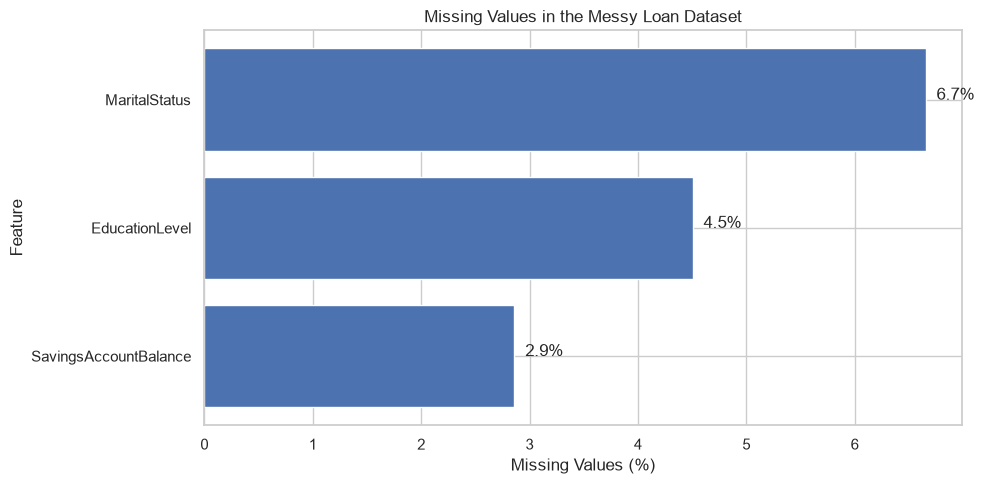

In [13]:
plt.figure(figsize=(10, 5))

missing_plot = missing_summary.sort_values("Missing_Percentage")

plt.barh(
    missing_plot.index,
    missing_plot["Missing_Percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values in the Messy Loan Dataset")

for i, value in enumerate(missing_plot["Missing_Percentage"]):
    plt.text(value + 0.1, i, f"{value:.1f}%")

plt.tight_layout()
plt.show()

## 2.5 Duplicate Records

Duplicate records can distort distributions and model evaluation. We therefore check whether 
the dataset contains exact duplicate rows.

In [14]:
print("Duplicate rows in messy dataset:", messy.duplicated().sum())
print("Duplicate rows in reference dataset:", reference.duplicated().sum())

Duplicate rows in messy dataset: 0
Duplicate rows in reference dataset: 0


## 2.6 Target Variables

The project supports two modeling approaches:

- **Classification:** `LoanApproved`
- **Regression:** `RiskScore`

Both targets are examined before deciding how they will be modeled.

In [15]:
print("LoanApproved distribution:")
display(
    messy["LoanApproved"]
    .value_counts()
    .rename_axis("LoanApproved")
    .reset_index(name="Count")
)

print("\nLoanApproved percentage:")
display(
    messy["LoanApproved"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("LoanApproved")
    .reset_index(name="Percentage")
)

print("\nRiskScore summary:")
display(messy["RiskScore"].describe())

LoanApproved distribution:


,LoanApproved,Count
0,0,15220
1,1,4780



LoanApproved percentage:


,LoanApproved,Percentage
0,0,76.100
1,1,23.900



RiskScore summary:


count   20,000.000
mean        50.767
std          7.778
min         28.800
25%         46.000
50%         52.000
75%         56.000
max         84.000
Name: RiskScore, dtype: float64

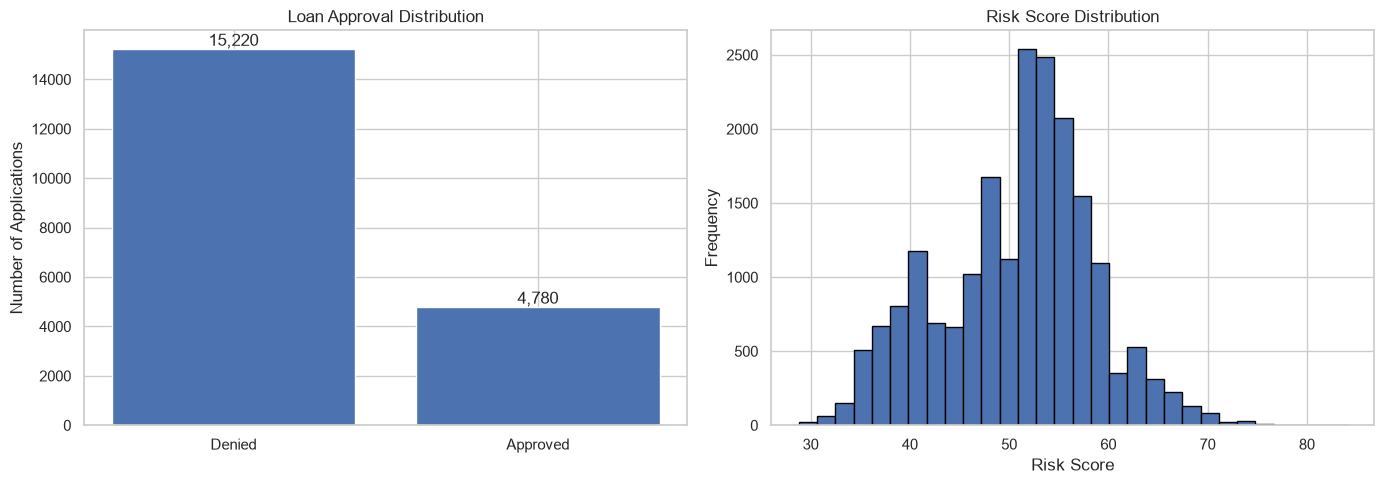

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification target
approval_counts = messy["LoanApproved"].value_counts().sort_index()

axes[0].bar(
    ["Denied", "Approved"],
    approval_counts.values
)

axes[0].set_title("Loan Approval Distribution")
axes[0].set_ylabel("Number of Applications")

for i, value in enumerate(approval_counts.values):
    axes[0].text(i, value, f"{value:,}", ha="center", va="bottom")

# Regression target
axes[1].hist(
    messy["RiskScore"],
    bins=30,
    edgecolor="black"
)

axes[1].set_title("Risk Score Distribution")
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2.7 Feature Types

Features are classified according to how they should be treated during preprocessing.

- **Numerical:** continuous or count-based measurements.
- **Categorical:** nominal categories without a natural order.
- **Ordinal:** categories with a meaningful order.
- **Targets:** variables being predicted.

In [17]:
# Exclude the two modeling targets from predictor classification
target_columns = ["LoanApproved", "RiskScore"]

feature_columns = [
    col for col in messy.columns
    if col not in target_columns
]

# Identify numerical and categorical features
numerical_features = messy[feature_columns].select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = messy[feature_columns].select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Create a feature classification table
feature_type_df = pd.DataFrame({
    "Feature": feature_columns,
    "Data Type": [messy[col].dtype for col in feature_columns],
    "Feature Type": [
        "Numerical" if col in numerical_features else "Categorical"
        for col in feature_columns
    ],
    "Missing Values": [
        messy[col].isna().sum()
        for col in feature_columns
    ],
    "Missing (%)": [
        messy[col].isna().mean() * 100
        for col in feature_columns
    ],
    "Unique Values": [
        messy[col].nunique(dropna=True)
        for col in feature_columns
    ]
})

# Add ordinal classification
feature_type_df.loc[
    feature_type_df["Feature"] == "EducationLevel",
    "Feature Type"
] = "Ordinal"

# Display neatly
display(
    feature_type_df.style
    .format({"Missing (%)": "{:.2f}%"})
    .set_caption("Feature Classification and Data Quality Summary")
)

C:\Users\user\AppData\Local\Temp\ipykernel_11332\2705690646.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = messy[feature_columns].select_dtypes(


,Feature,Data Type,Feature Type,Missing Values,Missing (%),Unique Values
0,Age,int64,Numerical,0,0.00%,63
1,AnnualIncome,str,Categorical,0,0.00%,17516
2,CreditScore,int64,Numerical,0,0.00%,322
3,EmploymentStatus,str,Categorical,0,0.00%,3
4,EducationLevel,str,Ordinal,901,4.50%,5
5,Experience,int64,Numerical,0,0.00%,62
6,LoanAmount,int64,Numerical,0,0.00%,15578
7,LoanDuration,int64,Numerical,0,0.00%,10
8,MaritalStatus,str,Categorical,1331,6.65%,4
9,NumberOfDependents,int64,Numerical,0,0.00%,6


### Ordinal Features

`EducationLevel` contains ordered categories:

High School → Associate → Bachelor → Master → Doctorate

Although it is stored as a categorical variable, its levels have an inherent order. 
This will be considered during preprocessing rather than treating the levels as purely 
nominal categories.

## 2.8 Numerical Feature Distributions

Numerical distributions are examined to identify:

- skewness
- unusual ranges
- potential outliers
- variables requiring transformation or scaling

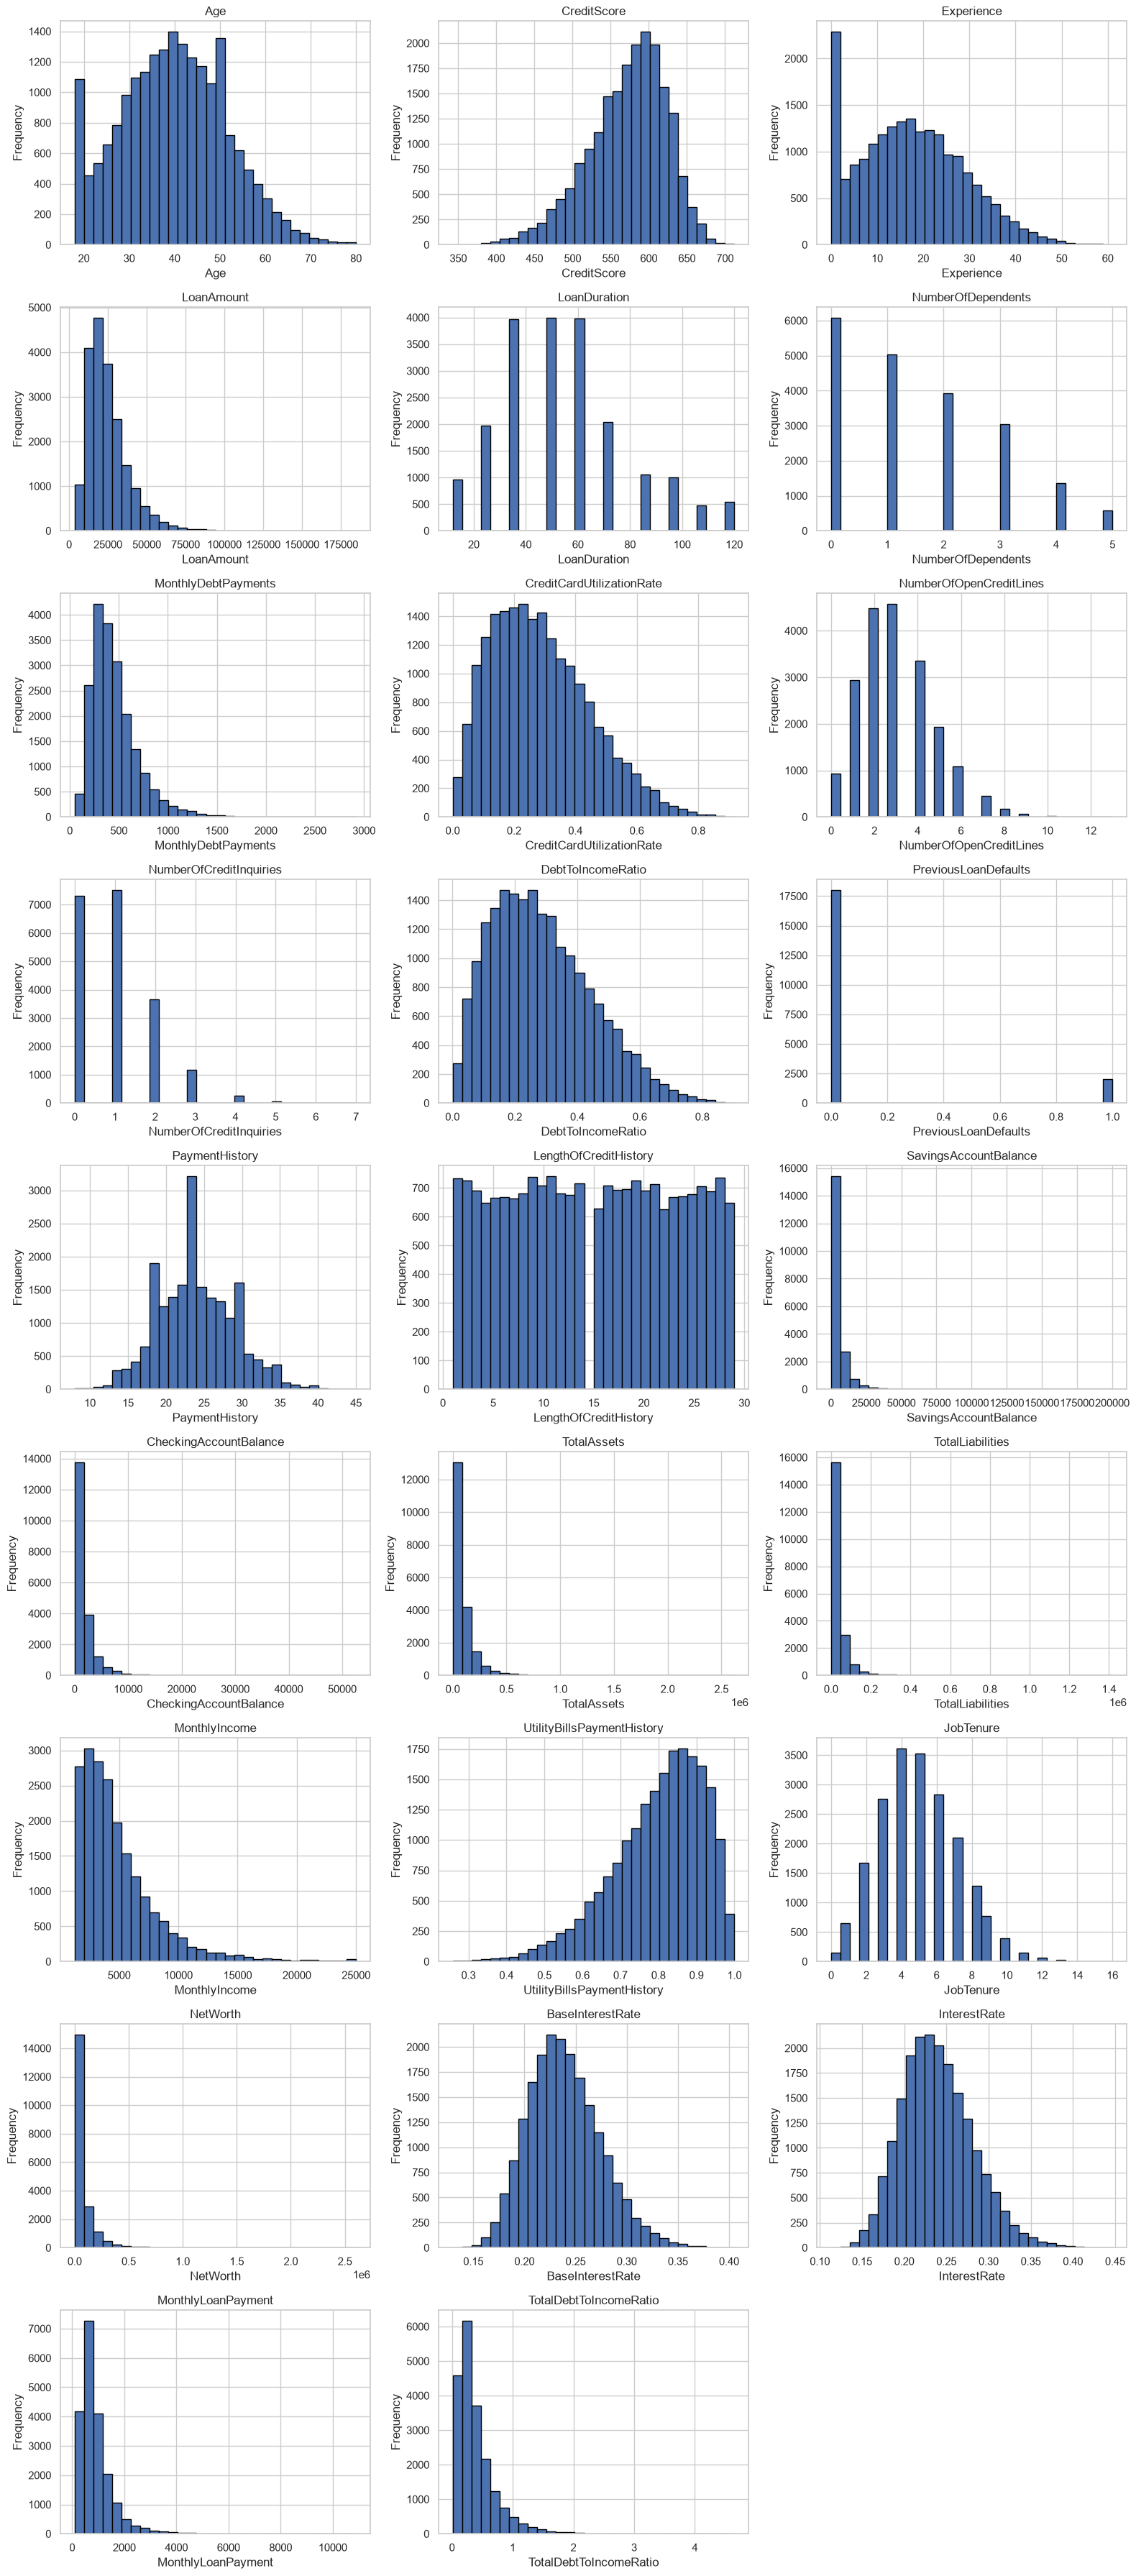

In [18]:
# Exclude targets
numeric_eda = [
    col for col in numerical_features
    if col not in ["LoanApproved", "RiskScore"]
]

n_cols = 3
n_rows = int(np.ceil(len(numeric_eda) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 4)
)

axes = np.array(axes).ravel()

for ax, col in zip(axes, numeric_eda):
    ax.hist(
        messy[col].dropna(),
        bins=30,
        edgecolor="black"
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(numeric_eda):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
numeric_summary = messy[numeric_eda].describe().T

numeric_summary["Skewness"] = messy[numeric_eda].skew()

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,Skewness
Age,"20,000.000",39.753,11.623,18.000,32.000,40.000,48.000,80.000,0.186
CreditScore,"20,000.000",571.612,50.997,343.000,540.000,578.000,609.000,712.000,-0.597
Experience,"20,000.000",17.523,11.317,0.000,9.000,17.000,25.000,61.000,0.340
LoanAmount,"20,000.000","24,882.868","13,427.421","3,674.000","15,575.000","21,914.500","30,835.000","184,732.000",1.834
LoanDuration,"20,000.000",54.057,24.665,12.000,36.000,48.000,72.000,120.000,0.651
NumberOfDependents,"20,000.000",1.517,1.386,0.000,0.000,1.000,2.000,5.000,0.640
MonthlyDebtPayments,"20,000.000",454.293,240.508,50.000,286.000,402.000,564.000,"2,919.000",1.653
CreditCardUtilizationRate,"20,000.000",0.286,0.160,0.001,0.161,0.267,0.391,0.917,0.601
NumberOfOpenCreditLines,"20,000.000",3.023,1.736,0.000,2.000,3.000,4.000,13.000,0.600
NumberOfCreditInquiries,"20,000.000",0.993,0.987,0.000,0.000,1.000,2.000,7.000,1.012


## 2.9 Categorical Feature Distributions

Categorical variables are examined to identify dominant categories, rare categories, and 
potential missing-value patterns.

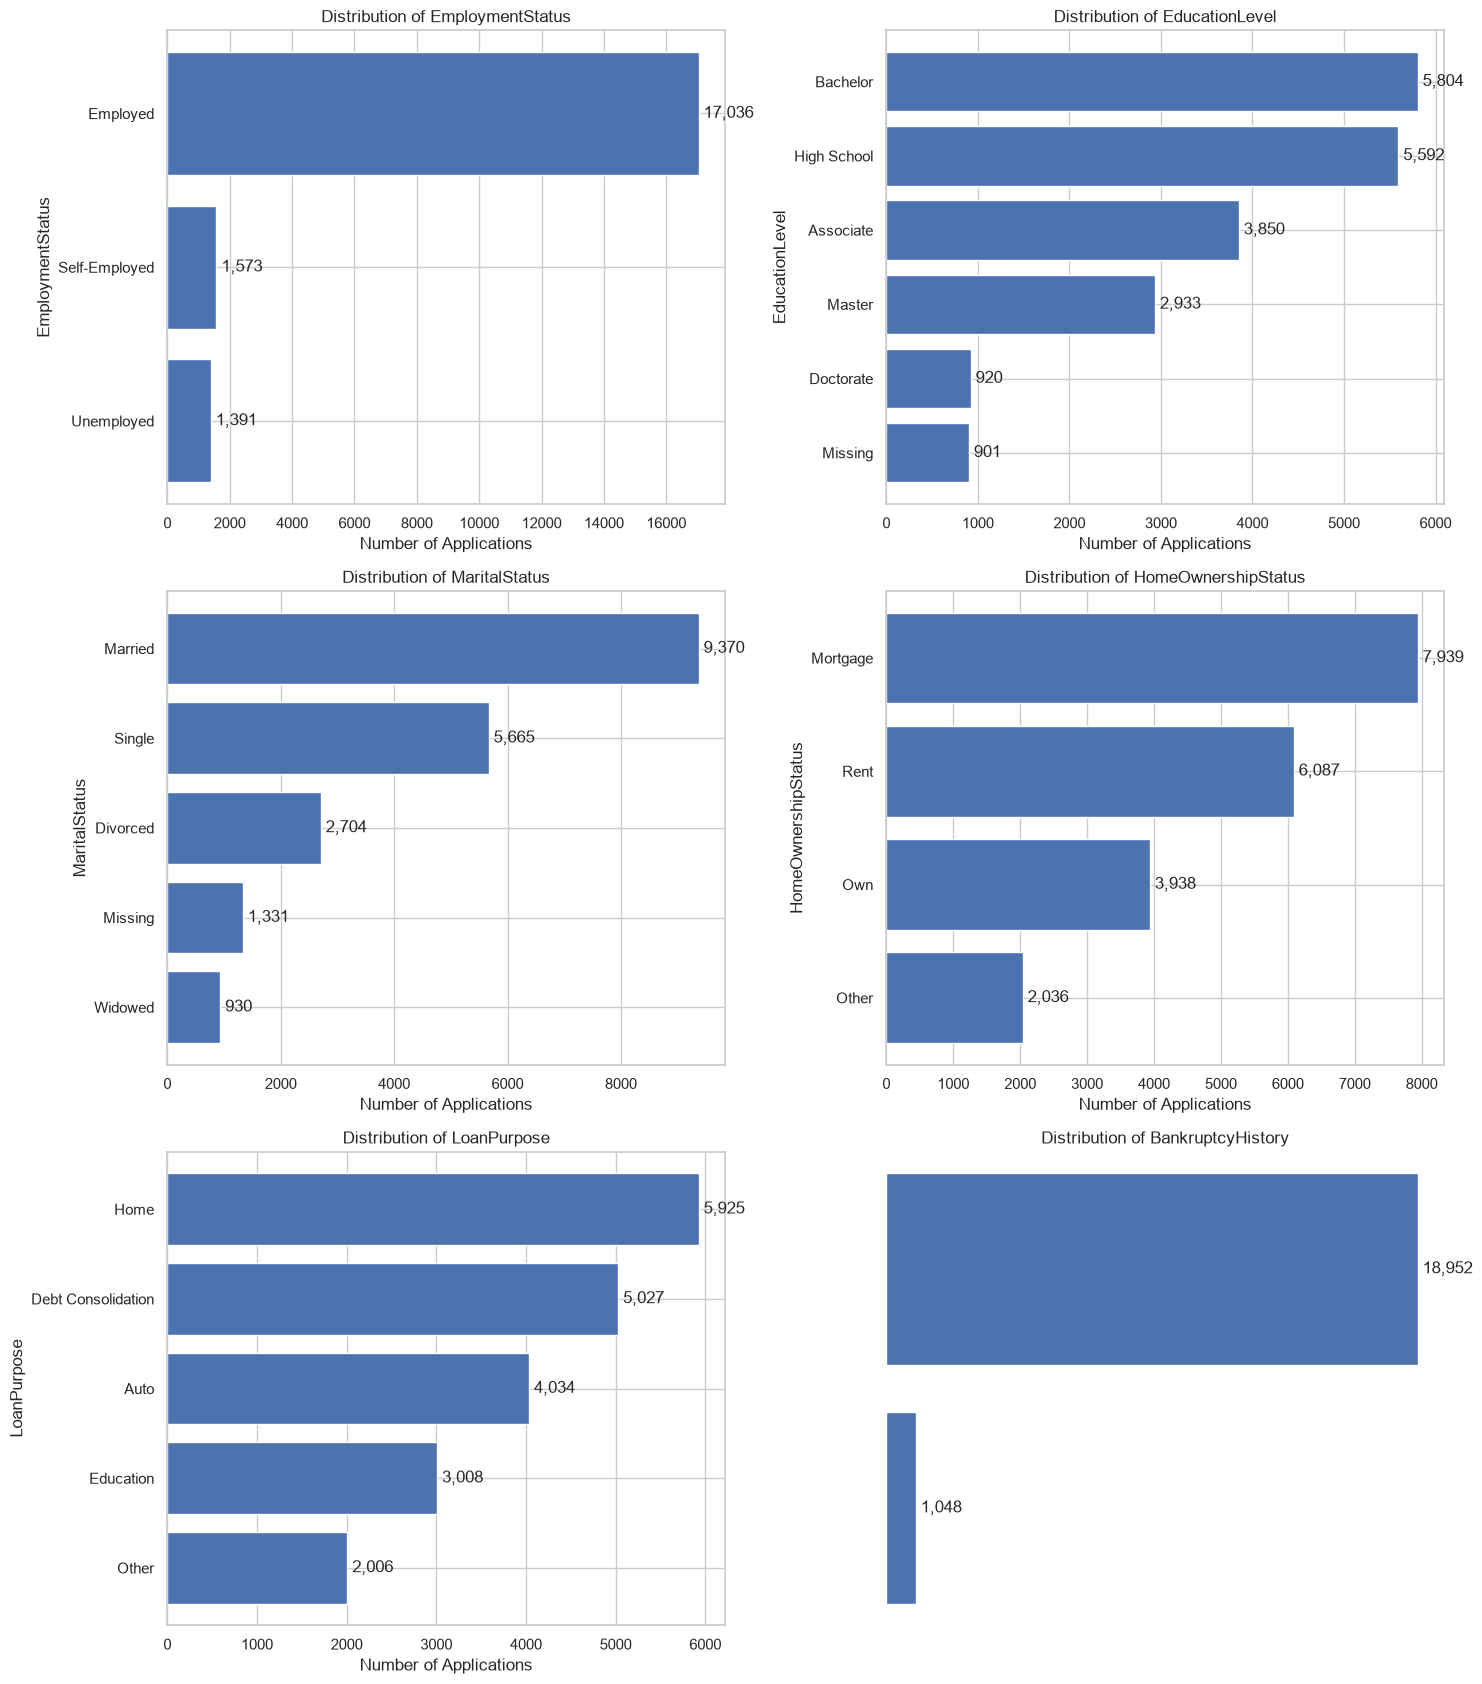

In [20]:
cat_eda = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "BankruptcyHistory"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 17))

for ax, col in zip(axes.ravel(), cat_eda):

    values = messy[col].fillna("Missing").astype(str)

    counts = values.value_counts()

    ax.barh(
        counts.index,
        counts.values
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("Number of Applications")
    ax.set_ylabel(col)

    ax.invert_yaxis()

    for i, value in enumerate(counts.values):
        ax.text(
            value,
            i,
            f" {value:,}",
            va="center"
        )

axes.ravel()[-1].axis("off")

plt.tight_layout()
plt.show()

## 2.10 Approval Rates Across Categorical Features

Approval rates are compared across important categorical variables to identify potential 
relationships between applicant characteristics and historical loan decisions.

Missing values are retained as a separate category during EDA.

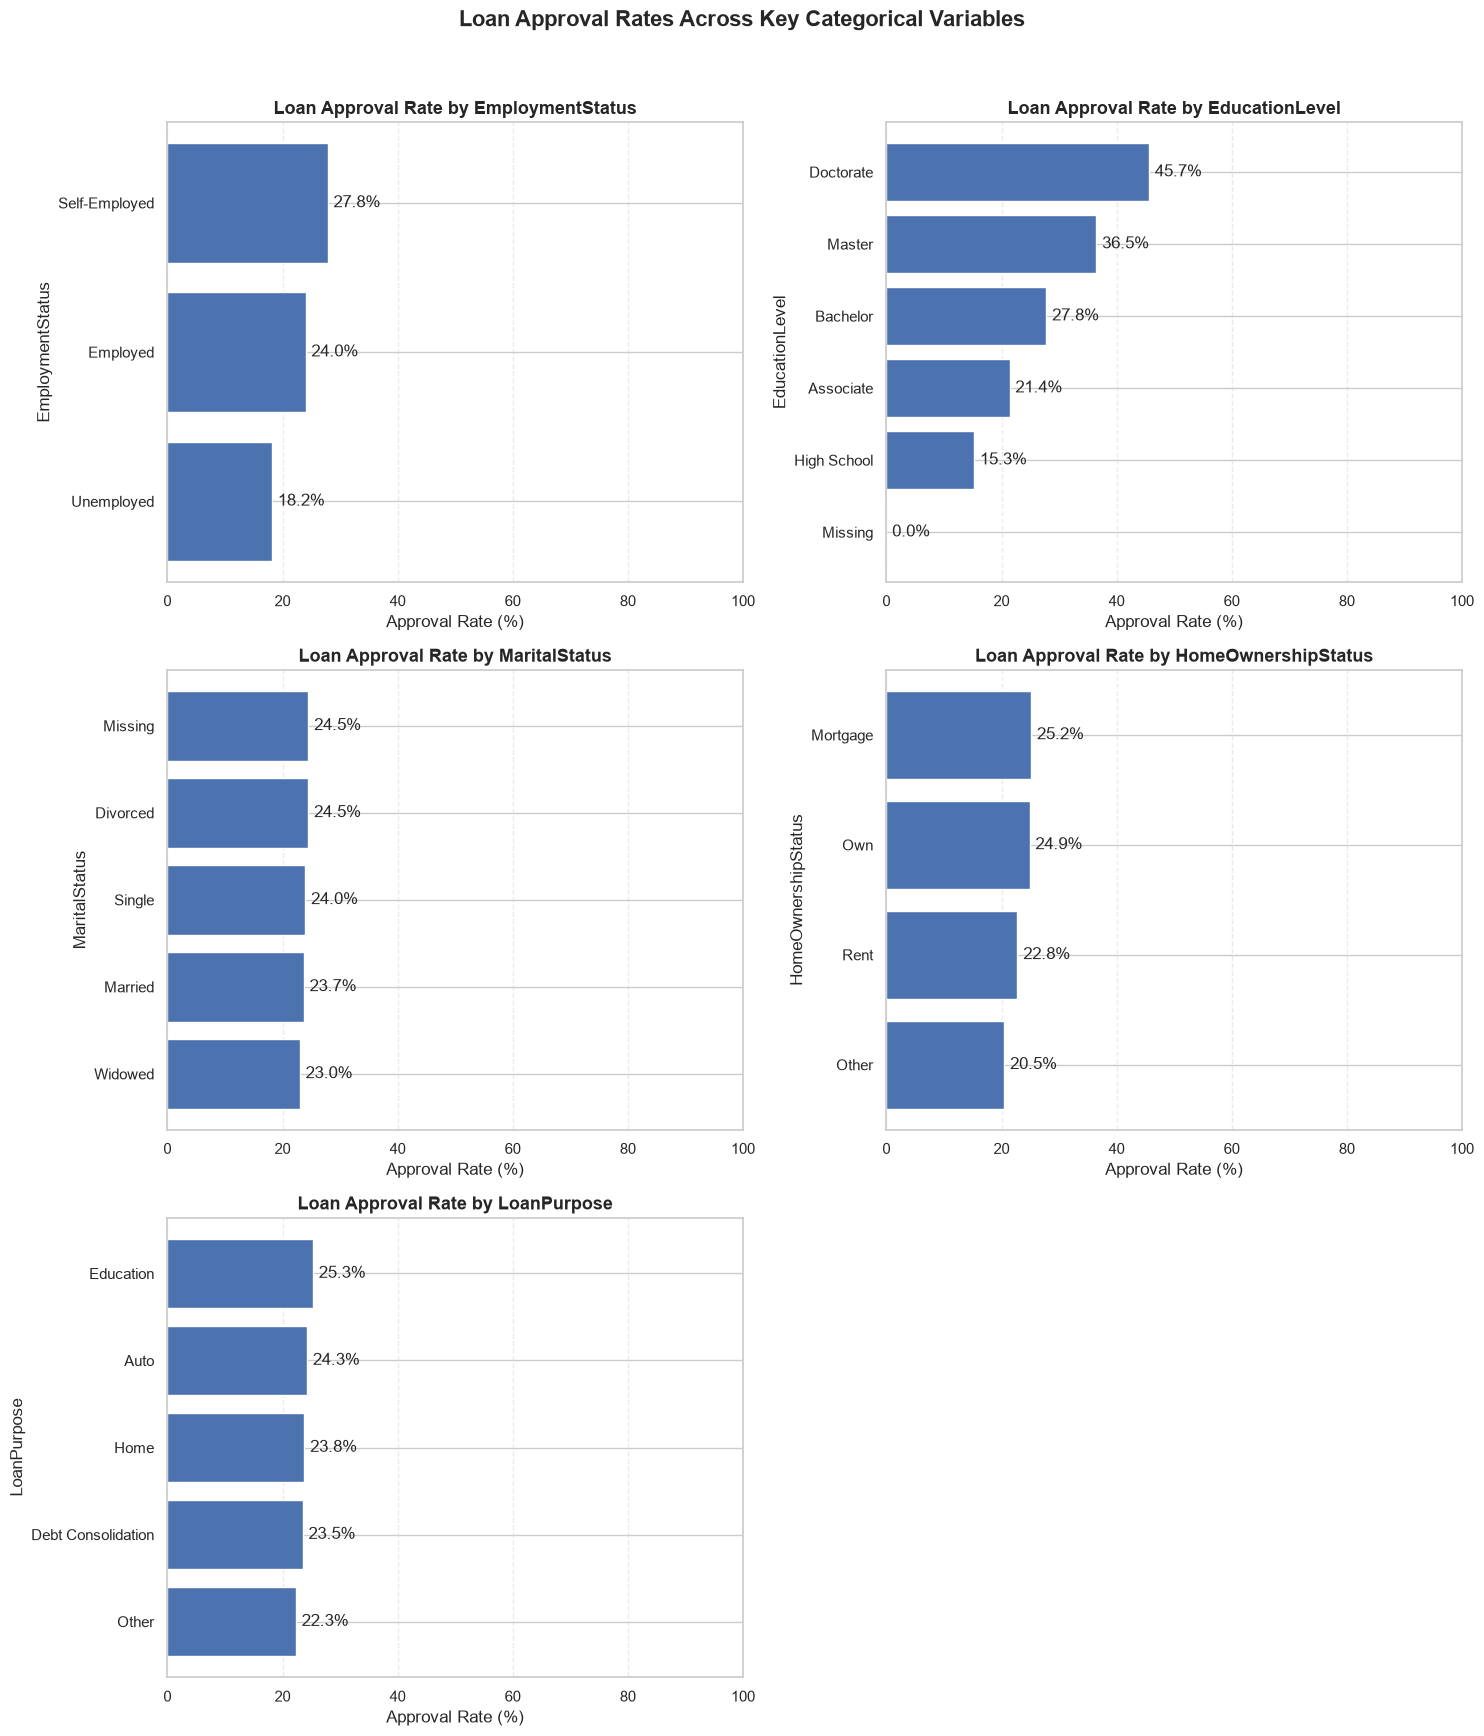

In [21]:
cat_eda = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 17))

for ax, col in zip(axes.ravel(), cat_eda):

    temp = messy[[col, "LoanApproved"]].copy()

    temp[col] = temp[col].fillna("Missing").astype(str)

    rates = (
        temp.groupby(col)["LoanApproved"]
        .mean()
        .sort_values(ascending=False)
    )

    approval_rates = rates * 100

    ax.barh(
        approval_rates.index.tolist(),
        approval_rates.values
    )

    ax.set_title(
        f"Loan Approval Rate by {col}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Approval Rate (%)")
    ax.set_ylabel(col)

    ax.invert_yaxis()

    max_rate = approval_rates.max()

    ax.set_xlim(
        0,
        max(100, max_rate * 1.15)
    )

    for i, value in enumerate(approval_rates.values):
        ax.text(
            value + 1,
            i,
            f"{value:.1f}%",
            va="center"
        )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.4
    )

axes.ravel()[-1].axis("off")

plt.suptitle(
    "Loan Approval Rates Across Key Categorical Variables",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## 2.11 Relationships Between Numerical Features

Correlation analysis is used to identify relationships between numerical variables and 
potentially redundant features.

Correlation does not establish causation.

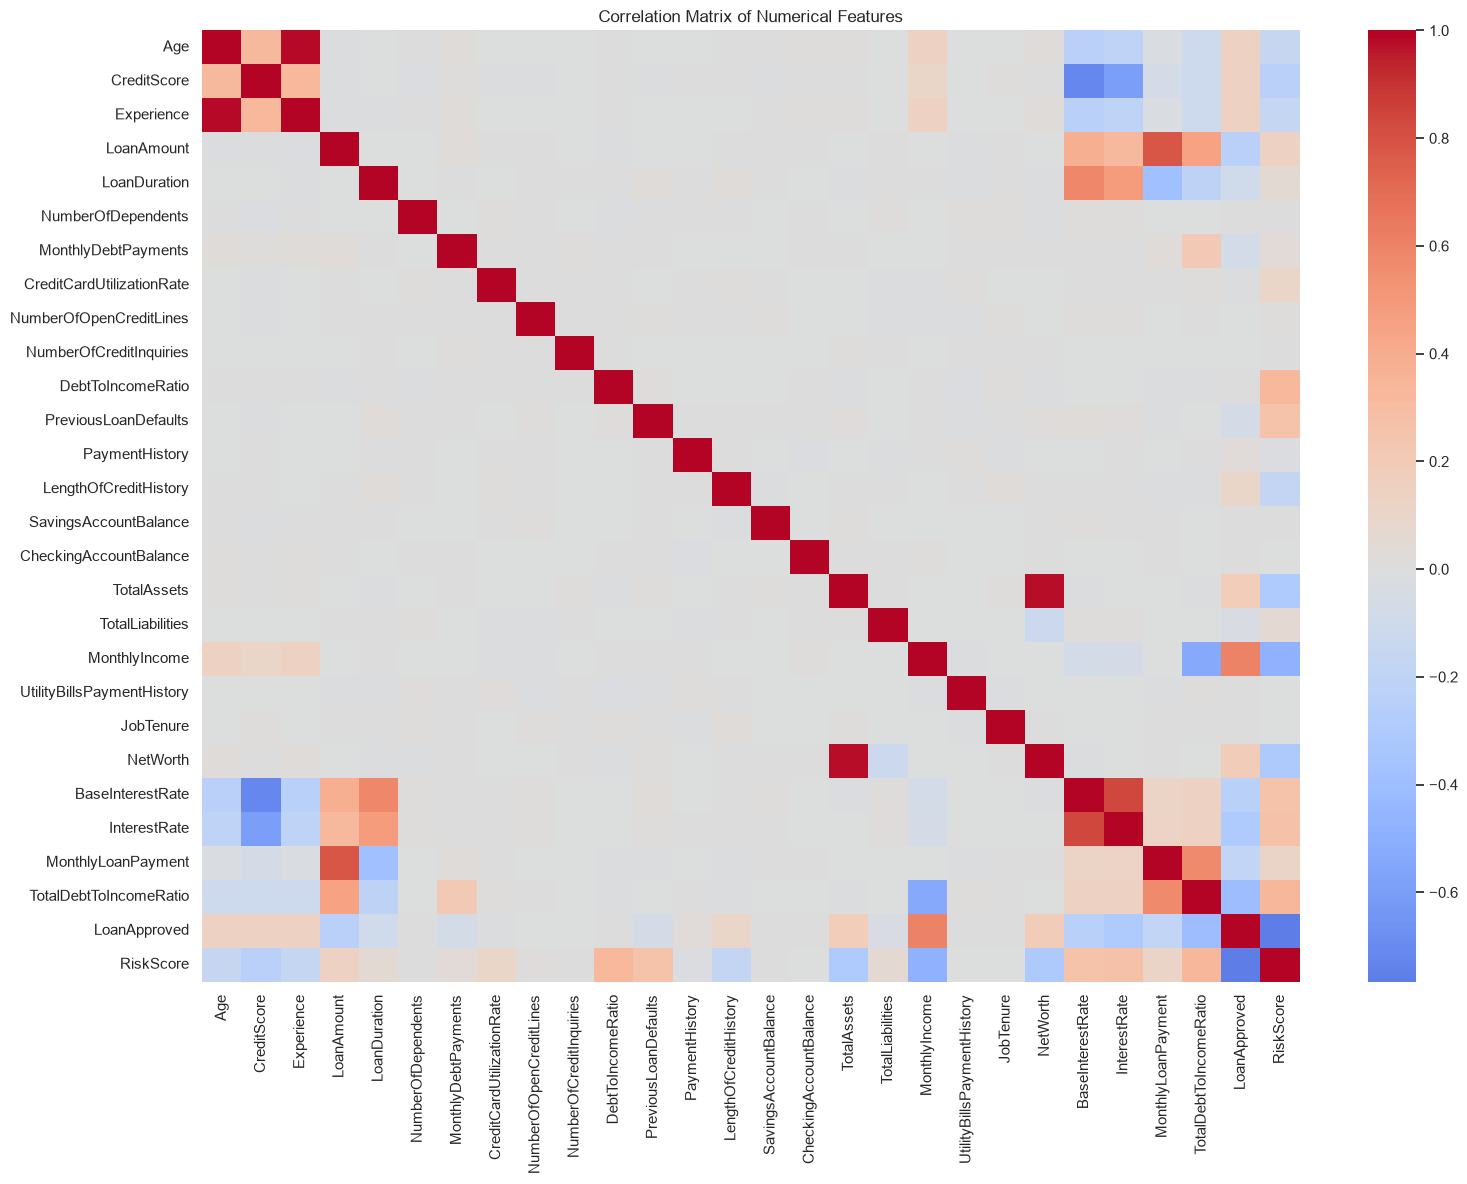

In [22]:
corr_features = numeric_eda + ["LoanApproved", "RiskScore"]

correlation_matrix = messy[corr_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [23]:
approval_corr = (
    correlation_matrix["LoanApproved"]
    .drop(["LoanApproved", "RiskScore"])
    .abs()
    .sort_values(ascending=False)
)

risk_corr = (
    correlation_matrix["RiskScore"]
    .drop(["LoanApproved", "RiskScore"])
    .abs()
    .sort_values(ascending=False)
)

print("Strongest numerical relationships with LoanApproved:")
display(approval_corr.head(10))

print("\nStrongest numerical relationships with RiskScore:")
display(risk_corr.head(10))

Strongest numerical relationships with LoanApproved:


MonthlyIncome            0.604
TotalDebtToIncomeRatio   0.410
InterestRate             0.302
BaseInterestRate         0.247
LoanAmount               0.239
NetWorth                 0.188
MonthlyLoanPayment       0.184
TotalAssets              0.184
CreditScore              0.142
Age                      0.141
Name: LoanApproved, dtype: float64


Strongest numerical relationships with RiskScore:


MonthlyIncome            0.487
TotalDebtToIncomeRatio   0.343
DebtToIncomeRatio        0.327
NetWorth                 0.304
TotalAssets              0.297
InterestRate             0.268
PreviousLoanDefaults     0.259
BaseInterestRate         0.256
CreditScore              0.240
LengthOfCreditHistory    0.178
Name: RiskScore, dtype: float64

## 2.12 Numerical Features by Approval Status

Boxplots help identify differences in numerical variables between historically approved and 
denied applications and highlight potential outliers.

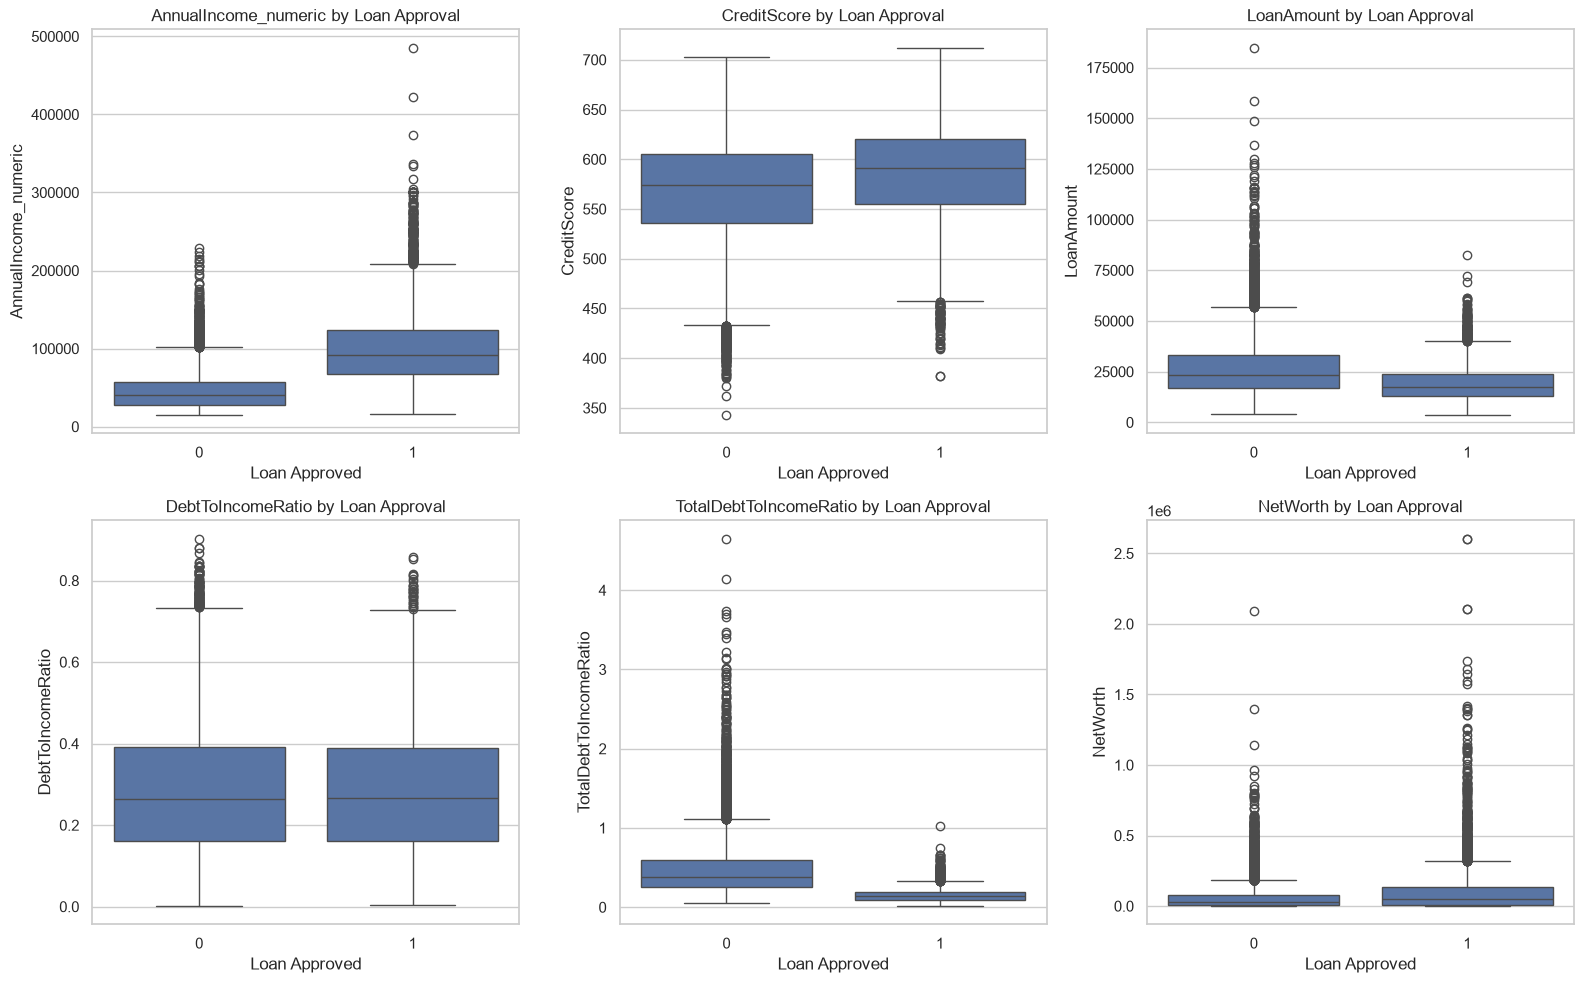

In [24]:
box_features = [
    "AnnualIncome",
    "CreditScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "TotalDebtToIncomeRatio",
    "NetWorth"
]

# Clean AnnualIncome only for visualization
plot_df = messy.copy()

plot_df["AnnualIncome_numeric"] = (
    plot_df["AnnualIncome"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

box_features = [
    "AnnualIncome_numeric",
    "CreditScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "TotalDebtToIncomeRatio",
    "NetWorth"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.ravel(), box_features):

    sns.boxplot(
        data=plot_df,
        x="LoanApproved",
        y=col,
        ax=ax
    )

    ax.set_title(f"{col} by Loan Approval")
    ax.set_xlabel("Loan Approved")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## 2.13 Outlier Analysis

Financial variables can contain extreme observations. These values may represent genuine 
high-value applicants or unusual observations rather than errors.

Outliers will therefore be investigated rather than automatically removed.

In [25]:
outlier_summary = []

for col in numeric_eda:

    q1 = messy[col].quantile(0.25)
    q3 = messy[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (messy[col] < lower_bound) |
        (messy[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Outlier_%": outliers / len(messy) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(
    outlier_summary
    .sort_values("Outlier_%", ascending=False)
)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
11,PreviousLoanDefaults,0.000,0.000,0.000,0.000,0.000,2001,10.005
21,NetWorth,"8,734.750","88,825.500","80,090.750","-111,401.375","208,961.625",1564,7.820
14,SavingsAccountBalance,"1,542.000","5,869.250","4,327.250","-4,948.875","12,360.125",1547,7.735
17,TotalLiabilities,"11,196.750","43,146.500","31,949.750","-36,727.875","91,071.125",1533,7.665
15,CheckingAccountBalance,551.000,"2,126.000","1,575.000","-1,811.500","4,488.500",1522,7.610
16,TotalAssets,"31,180.250","117,405.250","86,225.000","-98,157.250","246,742.750",1442,7.210
25,TotalDebtToIncomeRatio,0.180,0.509,0.330,-0.315,1.003,1152,5.760
24,MonthlyLoanPayment,493.764,"1,112.771",619.007,-434.747,"2,041.281",1089,5.445
18,MonthlyIncome,"2,629.583","6,163.000","3,533.417","-2,670.542","11,463.125",925,4.625
3,LoanAmount,"15,575.000","30,835.000","15,260.000","-7,315.000","53,725.000",746,3.730


## 2.14 Statistical Relationship Tests

Statistical tests are used to complement the visual analysis.

For numerical variables, a Mann–Whitney U test compares distributions between approved and 
denied applications.

For categorical variables, a chi-square test evaluates whether category membership and loan 
approval are statistically associated.

Statistical significance indicates evidence of an association; it does not establish causation.

In [26]:
# Mann-Whitney U tests
approval_0 = messy[messy["LoanApproved"] == 0]
approval_1 = messy[messy["LoanApproved"] == 1]

mann_whitney_results = []

for col in numeric_eda:

    x = approval_0[col].dropna()
    y = approval_1[col].dropna()

    if len(x) > 0 and len(y) > 0:
        statistic, p_value = stats.mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        mann_whitney_results.append({
            "Feature": col,
            "U_Statistic": statistic,
            "p_value": p_value
        })

mann_whitney_results = pd.DataFrame(mann_whitney_results)

mann_whitney_results["Significant_at_0.05"] = (
    mann_whitney_results["p_value"] < 0.05
)

display(
    mann_whitney_results.sort_values("p_value")
)

,Feature,U_Statistic,p_value,Significant_at_0.05
23,InterestRate,"51,541,026.500",0.000,True
25,TotalDebtToIncomeRatio,"65,940,891.000",0.000,True
18,MonthlyIncome,"8,365,584.000",0.000,True
3,LoanAmount,"49,186,943.500",0.000,True
22,BaseInterestRate,"48,643,189.500",0.000,True
24,MonthlyLoanPayment,"47,316,702.000",0.000,True
2,Experience,"29,258,640.500",0.000,True
0,Age,"29,316,482.000",0.000,True
1,CreditScore,"29,342,909.500",0.000,True
21,NetWorth,"29,443,175.000",0.000,True


In [27]:
chi_square_results = []

for col in cat_eda:

    contingency_table = pd.crosstab(
        messy[col].fillna("Missing"),
        messy["LoanApproved"]
    )

    chi2, p_value, dof, expected = stats.chi2_contingency(
        contingency_table
    )

    chi_square_results.append({
        "Feature": col,
        "Chi2": chi2,
        "Degrees_of_Freedom": dof,
        "p_value": p_value
    })

chi_square_results = pd.DataFrame(chi_square_results)

chi_square_results["Significant_at_0.05"] = (
    chi_square_results["p_value"] < 0.05
)

display(
    chi_square_results.sort_values("p_value")
)

,Feature,Chi2,Degrees_of_Freedom,p_value,Significant_at_0.05
1,EducationLevel,"1,068.928",5,0.000,True
0,EmploymentStatus,38.507,2,0.000,True
3,HomeOwnershipStatus,26.329,3,0.000,True
4,LoanPurpose,6.696,4,0.153,False
2,MaritalStatus,1.374,4,0.849,False


## 2.15 Data Quality Findings

The exploratory analysis identifies several issues that must be addressed during data 
preparation:

| Issue | Implication |
|---|---|
| `AnnualIncome` is stored as currency text in the messy dataset | Requires numeric conversion |
| Missing `EducationLevel` | Requires categorical/ordinal imputation |
| Missing `MaritalStatus` | Requires categorical imputation |
| Missing `SavingsAccountBalance` | Requires numerical imputation |
| `BankruptcyHistory` has different representations across datasets | Requires standardization |
| Numerical variables have different scales | Scaling is required for models such as Logistic Regression |
| Financial variables contain potential outliers | Outliers should be investigated and handled carefully |
| `EducationLevel` has an inherent order | Should be considered as an ordinal feature |
| `RiskScore` and `LoanApproved` are target variables | They must not be used as predictors for each other |
| `ApplicationDate` exists in the reference dataset | Can support temporal feature engineering |

The identified issues will be addressed systematically during the Data Preparation phase.

## 2.16 Potential Feature Engineering

Several features may provide additional information when transformed into meaningful ratios 
or time-based variables.

Potential candidates include:

- Loan amount relative to annual income
- Monthly loan payment relative to monthly income
- Net worth relative to income
- Assets relative to liabilities
- Credit history relative to applicant age
- Application year and month
- Loan duration groups

These transformations will only be created where they have a clear business interpretation 
and can be implemented without introducing target leakage.

## 2.17 Data Understanding Summary

The dataset contains 20,000 loan applications with a mixture of numerical, categorical, 
and ordinal information.

The exploratory analysis identified:

- differences between the messy and reference datasets
- missing values in selected variables
- mixed data representations
- varying numerical scales
- potential outliers
- relationships between applicant characteristics and historical loan outcomes
- potential feature engineering opportunities

The findings provide the basis for the next CRISP-DM stage:

**Data Preparation and Pipeline Development.**

## 3. Data Preparation

## 3.1 Data Cleaning

Before building the preprocessing pipelines, deterministic data-cleaning operations will be performed.

The cleaning will focus on:

- Converting `AnnualIncome` from currency-formatted text to numerical values.
- Standardizing `BankruptcyHistory` into a binary representation.
- Converting `ApplicationDate` into datetime format.
- Retaining genuine missing values for the Pipeline to handle later.

The reference dataset will only be used to validate observations and provide the missing `ApplicationDate`. Other missing predictor values will not be filled from the reference dataset.

### 3.1.1 Create a Working Copy

The raw dataset is preserved so that all cleaning decisions remain reproducible.


In [28]:
# Preserve the original dataset
df = messy.copy()

print("Original messy dataset shape:", messy.shape)
print("Working dataset shape:", df.shape)

Original messy dataset shape: (20000, 35)
Working dataset shape: (20000, 35)


### 3.1.2 Check for a Valid Identifier

A merge should only be performed using a genuine identifier or after row correspondence has been demonstrated. `Application_ID` is not present in either dataset, so we will not invent a key or assume that matching row numbers are automatically equivalent.


In [29]:
print("Application_ID in messy:", "Application_ID" in messy.columns)
print("Application_ID in reference:", "Application_ID" in reference.columns)

common_columns = sorted(set(messy.columns).intersection(reference.columns))

display(
    pd.DataFrame({"Common Columns": common_columns})
)


Application_ID in messy: False
Application_ID in reference: False


,Common Columns
0,Age
1,AnnualIncome
2,BankruptcyHistory
3,BaseInterestRate
4,CheckingAccountBalance
5,CreditCardUtilizationRate
6,CreditScore
7,DebtToIncomeRatio
8,EducationLevel
9,EmploymentStatus


### 3.1.3 Match and Compare the Reference and Messy Datasets

Since neither dataset contains a unique application identifier, we will determine whether the observations correspond by comparing their common columns.

The comparison will:

1. Identify columns shared by both datasets.
2. Normalize differences in representation, such as currency formatting and binary values.
3. Create a row-level matching key from the common columns.
4. Check whether each messy observation has exactly one corresponding reference observation.
5. Compare the matched observations.
6. If correspondence is sufficiently demonstrated, bring `ApplicationDate` from the reference dataset into the messy dataset.

We will not assume that identical row positions imply identical observations.

In [30]:
# ============================================================
# Match Messy and Reference Datasets Using Stable Columns
# Then Add ApplicationDate to the Messy Dataset
# ============================================================

# Columns that contain missing values in the messy dataset
# and therefore should NOT be used as part of the matching key
problematic_columns = [
    "MaritalStatus",
    "EducationLevel",
    "SavingsAccountBalance"
]

# MonthlyLoanPayment has one mismatch, so exclude it from the
# matching key as well and investigate it separately later
problematic_columns.append("MonthlyLoanPayment")


# ------------------------------------------------------------
# 1. Select stable common columns
# ------------------------------------------------------------

matching_columns = [
    col for col in common_columns
    if col not in problematic_columns
]

print("Number of stable matching columns:", len(matching_columns))
print("Excluded from matching:", problematic_columns)


# ------------------------------------------------------------
# 2. Create copies for matching
# ------------------------------------------------------------

messy_match = messy[matching_columns].copy()
reference_match = reference[matching_columns].copy()


# ------------------------------------------------------------
# 3. Normalize values
# ------------------------------------------------------------

def normalize_value(value):

    if pd.isna(value):
        return "<MISSING>"

    # Numeric values
    if isinstance(value, (int, float, np.integer, np.floating)):

        if float(value).is_integer():
            return str(int(value))

        return str(round(float(value), 10))

    value = str(value).strip()

    # Remove currency formatting
    value = value.replace("$", "").replace(",", "")

    # Normalize binary representations
    binary_map = {
        "yes": "1",
        "no": "0",
        "true": "1",
        "false": "0"
    }

    value_lower = value.lower()

    if value_lower in binary_map:
        return binary_map[value_lower]

    # Normalize numeric strings
    try:

        numeric_value = float(value)

        if numeric_value.is_integer():
            return str(int(numeric_value))

        return str(round(numeric_value, 10))

    except ValueError:

        return value_lower


# Apply normalization
for column in matching_columns:

    messy_match[column] = messy_match[column].apply(
        normalize_value
    )

    reference_match[column] = reference_match[column].apply(
        normalize_value
    )


# ------------------------------------------------------------
# 4. Create a composite matching key
# ------------------------------------------------------------

messy_match["match_key"] = (
    messy_match[matching_columns]
    .astype(str)
    .agg("|".join, axis=1)
)

reference_match["match_key"] = (
    reference_match[matching_columns]
    .astype(str)
    .agg("|".join, axis=1)
)


# ------------------------------------------------------------
# 5. Check uniqueness of the matching key
# ------------------------------------------------------------

messy_duplicates = messy_match["match_key"].duplicated().sum()
reference_duplicates = reference_match["match_key"].duplicated().sum()

print("\nMatching key validation")
print("Duplicate keys in messy:", messy_duplicates)
print("Duplicate keys in reference:", reference_duplicates)


# ------------------------------------------------------------
# 6. Check how many rows can be matched
# ------------------------------------------------------------

reference_keys = set(reference_match["match_key"])

messy_match["Matched"] = (
    messy_match["match_key"].isin(reference_keys)
)

matched_rows = messy_match["Matched"].sum()
unmatched_rows = (~messy_match["Matched"]).sum()
match_rate = messy_match["Matched"].mean() * 100

match_summary = pd.DataFrame({
    "Metric": [
        "Messy observations",
        "Reference observations",
        "Stable matching columns",
        "Matched observations",
        "Unmatched observations",
        "Match rate (%)"
    ],
    "Value": [
        len(messy),
        len(reference),
        len(matching_columns),
        matched_rows,
        unmatched_rows,
        match_rate
    ]
})

display(
    match_summary.style.format({
        "Value": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 7. If correspondence is established, add ApplicationDate
# ------------------------------------------------------------

if (
    matched_rows == len(messy)
    and messy_duplicates == 0
    and reference_duplicates == 0
):

    print("\n✓ All messy observations have a unique reference match.")
    print("✓ Row correspondence has been established using stable features.")

    # Create reference lookup
    reference_lookup = reference[
        matching_columns + ["ApplicationDate"]
    ].copy()

    reference_lookup["match_key"] = (
        reference_match["match_key"].values
    )

    # Start from the original messy dataset
    df = messy.copy()

    # Create matching key in original messy data
    messy_key = (
        messy_match["match_key"]
    )

    df["match_key"] = messy_key.values

    # Add ApplicationDate
    df = df.merge(
        reference_lookup[
            ["match_key", "ApplicationDate"]
        ],
        on="match_key",
        how="left",
        validate="one_to_one"
    )

    # Remove temporary key
    df.drop(columns="match_key", inplace=True)

    # Convert ApplicationDate
    df["ApplicationDate"] = pd.to_datetime(
        df["ApplicationDate"],
        errors="coerce"
    )

    print("\n✓ ApplicationDate successfully added to df.")

    print(
        "Missing ApplicationDate:",
        df["ApplicationDate"].isna().sum()
    )

    print("Final dataframe shape:", df.shape)

    display(
        df[
            ["ApplicationDate"]
        ].head()
    )

else:

    print(
        "\n⚠ Complete correspondence has NOT yet been established."
    )
    print(
        "Do not add ApplicationDate yet."
    )

Number of stable matching columns: 31
Excluded from matching: ['MaritalStatus', 'EducationLevel', 'SavingsAccountBalance', 'MonthlyLoanPayment']

Matching key validation
Duplicate keys in messy: 0
Duplicate keys in reference: 0


,Metric,Value
0,Messy observations,"20,000.00"
1,Reference observations,"20,000.00"
2,Stable matching columns,31.00
3,Matched observations,"20,000.00"
4,Unmatched observations,0.00
5,Match rate (%),100.00



✓ All messy observations have a unique reference match.
✓ Row correspondence has been established using stable features.

✓ ApplicationDate successfully added to df.
Missing ApplicationDate: 0
Final dataframe shape: (20000, 36)


,ApplicationDate
0,2018-01-01
1,2018-01-02
2,2018-01-03
3,2018-01-04
4,2018-01-05


## 3.1.4 Data Cleaning

The data-cleaning stage will address deterministic data-quality issues identified during EDA.

The cleaning will focus on:

- Converting `AnnualIncome` from currency-formatted text to numeric.
- Standardizing `BankruptcyHistory` into a binary representation.
- Converting `ApplicationDate` to datetime.
- Checking for duplicate observations.
- Checking for invalid or unexpected values.
- Reviewing remaining missing values.

Missing values will not be manually imputed at this stage. They will be handled later inside the modeling pipelines using `SimpleImputer`, ensuring that imputation parameters are learned from the training data only.

In [31]:
# Create a working copy for data cleaning
df_clean = df.copy()

print("Starting shape:", df_clean.shape)

Starting shape: (20000, 36)


In [32]:
# Convert AnnualIncome from currency-formatted text to numeric
df_clean["AnnualIncome"] = pd.to_numeric(
    df_clean["AnnualIncome"]
    .astype("string")
    .str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

# Check result
display(
    df_clean[["AnnualIncome"]].head()
)

print("AnnualIncome dtype:", df_clean["AnnualIncome"].dtype)

,AnnualIncome
0,"39,948.000"
1,"39,709.000"
2,"40,724.000"
3,"69,084.000"
4,"103,264.000"


AnnualIncome dtype: Float64


In [33]:
print(
    "Missing AnnualIncome values:",
    df_clean["AnnualIncome"].isna().sum()
)

Missing AnnualIncome values: 0


In [34]:
# Standardize BankruptcyHistory
df_clean["BankruptcyHistory"] = (
    df_clean["BankruptcyHistory"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0
    })
)

# Check the result
display(
    df_clean["BankruptcyHistory"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

,Count
BankruptcyHistory,
0,18952
1,1048


In [35]:
df_clean["ApplicationDate"] = pd.to_datetime(
    df_clean["ApplicationDate"],
    errors="coerce"
)

print(
    "ApplicationDate dtype:",
    df_clean["ApplicationDate"].dtype
)

print(
    "Missing ApplicationDate:",
    df_clean["ApplicationDate"].isna().sum()
)

ApplicationDate dtype: datetime64[us]
Missing ApplicationDate: 0


In [36]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [37]:
print("Original messy duplicates:", messy.duplicated().sum())
print("Cleaned dataset duplicates:", df_clean.duplicated().sum())

Original messy duplicates: 0
Cleaned dataset duplicates: 0


In [38]:
dtype_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type": [
        df_clean[col].dtype
        for col in df_clean.columns
    ],
    "Missing Values": [
        df_clean[col].isna().sum()
        for col in df_clean.columns
    ]
})

display(dtype_summary)

,Column,Data Type,Missing Values
0,Age,int64,0
1,AnnualIncome,Float64,0
2,CreditScore,int64,0
3,EmploymentStatus,str,0
4,EducationLevel,str,901
5,Experience,int64,0
6,LoanAmount,int64,0
7,LoanDuration,int64,0
8,MaritalStatus,str,1331
9,NumberOfDependents,int64,0


In [39]:
df_clean.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,ApplicationDate
0,45,"39,948.000",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354,1,2,0.358,0,Home,0,29,9,"7,632.000",1202,146111,19183,"3,329.000",0.725,11,126928,0.200,0.228,419.806,0.181,0,49.000,2018-01-01
1,38,"39,709.000",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.088,5,3,0.330,0,Debt Consolidation,0,21,9,"4,627.000",3460,53204,9595,"3,309.083",0.935,3,43609,0.207,0.201,794.054,0.390,0,52.000,2018-01-02
2,47,"40,724.000",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137,2,0,0.245,0,Education,0,20,22,886.000,895,25176,128874,"3,393.667",0.872,6,5205,0.218,0.213,666.407,0.462,0,52.000,2018-01-03
3,58,"69,084.000",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.268,2,1,0.436,0,Home,0,27,10,"1,675.000",1217,104822,5370,"5,757.000",0.896,5,99452,0.300,0.301,"1,047.507",0.313,0,54.000,2018-01-04
4,37,"103,264.000",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.321,0,0,0.079,0,Debt Consolidation,0,26,27,"1,555.000",4981,244305,17286,"8,605.333",0.941,5,227019,0.197,0.176,330.179,0.070,1,36.000,2018-01-05


### 5.1 Preprocessing Tools

The preprocessing workflow will use scikit-learn `Pipeline` and `ColumnTransformer`.

`Pipeline` ensures that preprocessing steps are executed in the correct order and learned only from the training data.

`ColumnTransformer` allows different preprocessing strategies to be applied to numerical, categorical, and ordinal features.

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

### 5.2 Feature Engineering

Additional features will be created from information that would be available at the time of loan application.

The engineered features will capture:

- Application timing
- Loan size relative to income
- Monthly payment burden
- Net worth relative to income
- Assets relative to liabilities
- Credit history relative to applicant age

The target variables `LoanApproved` and `RiskScore` will not be used to create these features.

In [41]:
df_clean["ApplicationYear"] = df_clean["ApplicationDate"].dt.year
df_clean["ApplicationMonth"] = df_clean["ApplicationDate"].dt.month
df_clean["ApplicationQuarter"] = df_clean["ApplicationDate"].dt.quarter

def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator

df_clean["LoanToIncome"] = safe_divide(
    df_clean["LoanAmount"],
    df_clean["AnnualIncome"]
)

df_clean["MonthlyPaymentToIncome"] = safe_divide(
    df_clean["MonthlyLoanPayment"],
    df_clean["MonthlyIncome"]
)

df_clean["NetWorthToIncome"] = safe_divide(
    df_clean["NetWorth"],
    df_clean["AnnualIncome"]
)

df_clean["AssetToLiabilityRatio"] = safe_divide(
    df_clean["TotalAssets"],
    df_clean["TotalLiabilities"]
)

df_clean["CreditHistoryToAge"] = safe_divide(
    df_clean["LengthOfCreditHistory"],
    df_clean["Age"]
)

In [42]:
TARGET_CLASS = "LoanApproved"
TARGET_REG = "RiskScore"

target_columns = [TARGET_CLASS, TARGET_REG]

feature_columns = [
    col for col in df_clean.columns
    if col not in target_columns
]

feature_columns.remove("ApplicationDate")

In [43]:
df_clean.head() 

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,ApplicationDate,ApplicationYear,ApplicationMonth,ApplicationQuarter,LoanToIncome,MonthlyPaymentToIncome,NetWorthToIncome,AssetToLiabilityRatio,CreditHistoryToAge
0,45,"39,948.000",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354,1,2,0.358,0,Home,0,29,9,"7,632.000",1202,146111,19183,"3,329.000",0.725,11,126928,0.200,0.228,419.806,0.181,0,49.000,2018-01-01,2018,1,1,0.329,0.126,3.177,7.617,0.200
1,38,"39,709.000",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.088,5,3,0.330,0,Debt Consolidation,0,21,9,"4,627.000",3460,53204,9595,"3,309.083",0.935,3,43609,0.207,0.201,794.054,0.390,0,52.000,2018-01-02,2018,1,1,0.656,0.240,1.098,5.545,0.237
2,47,"40,724.000",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137,2,0,0.245,0,Education,0,20,22,886.000,895,25176,128874,"3,393.667",0.872,6,5205,0.218,0.213,666.407,0.462,0,52.000,2018-01-03,2018,1,1,0.433,0.196,0.128,0.195,0.468
3,58,"69,084.000",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.268,2,1,0.436,0,Home,0,27,10,"1,675.000",1217,104822,5370,"5,757.000",0.896,5,99452,0.300,0.301,"1,047.507",0.313,0,54.000,2018-01-04,2018,1,1,0.549,0.182,1.440,19.520,0.172
4,37,"103,264.000",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.321,0,0,0.079,0,Debt Consolidation,0,26,27,"1,555.000",4981,244305,17286,"8,605.333",0.941,5,227019,0.197,0.176,330.179,0.070,1,36.000,2018-01-05,2018,1,1,0.089,0.038,2.198,14.133,0.730


In [44]:
df_clean.shape

(20000, 44)

# Part 3: Pipeline Development Phase

## 3.1 Preprocessing Strategy

The preprocessing strategy is designed to handle the different feature types in the cleaned loan application dataset while ensuring that preprocessing is learned only from the training data.

Three separate preprocessing flows will be created:

- **Numerical features:** median imputation followed by standardization.
- **Categorical features:** most-frequent imputation followed by one-hot encoding.
- **Ordinal features:** most-frequent imputation followed by ordinal encoding that preserves the natural ordering of education levels.

These flows will be combined using `ColumnTransformer` and integrated with the selected models using `Pipeline`. This provides a reproducible workflow and reduces the risk of data leakage during cross-validation and model training.

## 3.2 Import Preprocessing Tools

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

## 3.3 Define Modeling Targets and Predictors

The project contains two prediction tasks:

- **Classification:** predict `LoanApproved`.
- **Regression:** predict `RiskScore`.

Both target variables are excluded from the predictor set. This prevents either target from being used to predict the other and avoids target leakage.

In [46]:
TARGET_CLASS = "LoanApproved"
TARGET_REG = "RiskScore"

target_columns = [TARGET_CLASS, TARGET_REG]

feature_columns = [
    col for col in df_clean.columns
    if col not in target_columns
]

# ApplicationDate is used to create calendar features, but the raw
# datetime column is not passed directly to the models.
feature_columns.remove("ApplicationDate")

print("Number of predictors:", len(feature_columns))
print("Classification target:", TARGET_CLASS)
print("Regression target:", TARGET_REG)

Number of predictors: 41
Classification target: LoanApproved
Regression target: RiskScore


## 3.4 Define Feature Groups

Each predictor is assigned to exactly one preprocessing flow. `EducationLevel` is treated as ordinal because its categories have a natural progression, while the remaining text-based variables are treated as nominal categorical variables.

In [47]:
numeric_features = [
    "Age",
    "AnnualIncome",
    "CreditScore",
    "Experience",
    "LoanAmount",
    "LoanDuration",
    "NumberOfDependents",
    "MonthlyDebtPayments",
    "CreditCardUtilizationRate",
    "NumberOfOpenCreditLines",
    "NumberOfCreditInquiries",
    "DebtToIncomeRatio",
    "PreviousLoanDefaults",
    "PaymentHistory",
    "LengthOfCreditHistory",
    "SavingsAccountBalance",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "MonthlyIncome",
    "UtilityBillsPaymentHistory",
    "JobTenure",
    "NetWorth",
    "BaseInterestRate",
    "InterestRate",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio",
    "ApplicationYear",
    "ApplicationMonth",
    "ApplicationQuarter",
    "LoanToIncome",
    "MonthlyPaymentToIncome",
    "NetWorthToIncome",
    "AssetToLiabilityRatio",
    "CreditHistoryToAge"
]

categorical_features = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "BankruptcyHistory"
]

ordinal_features = [
    "EducationLevel"
]

In [48]:
all_grouped_features = (
    numeric_features
    + categorical_features
    + ordinal_features
)

feature_check = pd.DataFrame({
    "Feature": all_grouped_features,
    "Feature Type": (
        ["Numerical"] * len(numeric_features)
        + ["Categorical"] * len(categorical_features)
        + ["Ordinal"] * len(ordinal_features)
    )
})

display(feature_check)

print("Predictors expected:", len(feature_columns))
print("Predictors classified:", len(all_grouped_features))
print("Missing from feature groups:", set(feature_columns) - set(all_grouped_features))
print("Extra features in groups:", set(all_grouped_features) - set(feature_columns))

duplicates = [
    feature for feature in all_grouped_features
    if all_grouped_features.count(feature) > 1
]
print("Duplicated features:", set(duplicates))

,Feature,Feature Type
0,Age,Numerical
1,AnnualIncome,Numerical
2,CreditScore,Numerical
3,Experience,Numerical
4,LoanAmount,Numerical
5,LoanDuration,Numerical
6,NumberOfDependents,Numerical
7,MonthlyDebtPayments,Numerical
8,CreditCardUtilizationRate,Numerical
9,NumberOfOpenCreditLines,Numerical


Predictors expected: 41
Predictors classified: 41
Missing from feature groups: set()
Extra features in groups: set()
Duplicated features: set()


## 3.5 Numerical Feature Preprocessing

Numerical variables contain financial, credit, debt, loan and applicant information. Missing numerical values will be replaced using the **median**, which is less sensitive to extreme financial observations than the mean.

The variables are then standardized using `StandardScaler`. Scaling is particularly important for Logistic Regression because the model is sensitive to differences in feature scale. Although Random Forest does not require scaling, using the same structured preprocessing architecture keeps the workflow consistent.

In [49]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

## 3.6 Categorical Feature Preprocessing

Categorical variables will use most-frequent imputation for missing values and one-hot encoding for representation.

One-hot encoding avoids imposing an artificial numerical order on nominal categories. `handle_unknown="ignore"` allows the pipeline to process categories that appear in validation or test data but were not observed during training.

In [50]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

## 3.7 Ordinal Feature Preprocessing

`EducationLevel` has a meaningful order:

**High School → Associate → Bachelor → Master → Doctorate**

An `OrdinalEncoder` will preserve this ordering rather than treating each education category as unrelated.

In [51]:
education_categories = [[
    "High School",
    "Associate",
    "Bachelor",
    "Master",
    "Doctorate"
]]

ordinal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=education_categories
        ))
    ]
)

## 3.8 Combine the Preprocessing Flows

`ColumnTransformer` combines the three preprocessing flows into one transformation object. Each feature group is routed to the transformation appropriate for its data type.

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("ord", ordinal_transformer, ordinal_features)
    ],
    remainder="drop"
)

## 3.9 Consideration of FeatureUnion

`FeatureUnion` was considered because it can combine outputs from independent transformation pipelines. However, `ColumnTransformer` is more appropriate here because the preprocessing strategy is determined by **which columns belong to each feature type**.

Therefore, `FeatureUnion` is not necessary for the final implementation. Using it would add complexity without providing a clear benefit for this dataset.

# 4: Iterative Modeling Phase

## 4.1 Modeling Approach

The modeling phase implements the two prediction approaches defined during Business Understanding:

- **Classification:** Logistic Regression to predict `LoanApproved`.
- **Regression:** Random Forest Regressor to predict `RiskScore`.

The classification model is appropriate for the binary approval decision and provides interpretable coefficients. The Random Forest Regressor is used for the continuous risk-score target because it can capture nonlinear relationships and interactions among applicant characteristics.

The workflow uses an 80/20 train-test split and five-fold cross-validation. Cross-validation and hyperparameter tuning are performed only on the training data; the test set remains untouched until final evaluation.

## 4.2 Train/Test Split

The cleaned dataset is divided into training and testing sets using an 80/20 split. Stratification is based on `LoanApproved` so that the proportion of approved and denied applications is approximately preserved in both sets.

The same observations are used for both prediction tasks to maintain consistency between the classification and regression analyses.

In [53]:
from sklearn.model_selection import train_test_split

X = df_clean[feature_columns]
y_class = df_clean[TARGET_CLASS]
y_reg = df_clean[TARGET_REG]

(
    X_train,
    X_test,
    y_class_train,
    y_class_test,
    y_reg_train,
    y_reg_test
) = train_test_split(
    X,
    y_class,
    y_reg,
    test_size=0.20,
    stratify=y_class,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Classification training target:", y_class_train.shape)
print("Classification testing target:", y_class_test.shape)
print("Regression training target:", y_reg_train.shape)
print("Regression testing target:", y_reg_test.shape)

Training features: (16000, 41)
Testing features: (4000, 41)
Classification training target: (16000,)
Classification testing target: (4000,)
Regression training target: (16000,)
Regression testing target: (4000,)


## 4.3 Complete Model Pipelines

The preprocessing object is integrated directly into each model using `Pipeline`. This ensures that imputation, encoding and scaling are fitted as part of model training rather than on the complete dataset.

This is especially important during cross-validation because each fold must learn its preprocessing parameters from its own training portion.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

classification_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Classification pipeline created.")
print("Regression pipeline created.")

Classification pipeline created.
Regression pipeline created.


## 4.4 Validation Strategy and Metrics

Five-fold cross-validation will be used on the training data.

For classification, `StratifiedKFold` will preserve the approval/denial distribution across folds. The metrics are **Accuracy, Precision, Recall, F1-score and ROC-AUC**. Because false-positive and false-negative decisions have different financial consequences, business error cost will be examined during final evaluation and threshold analysis.

For regression, standard `KFold` cross-validation will be used with **MAE, RMSE and R²**.

The test set will not be used during cross-validation or hyperparameter tuning.

## 4.5 Baseline Classification Cross-Validation

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_validate

classification_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

classification_scores = cross_validate(
    classification_pipeline,
    X_train,
    y_class_train,
    cv=classification_cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

classification_cv_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean CV Score": [
        classification_scores["test_accuracy"].mean(),
        classification_scores["test_precision"].mean(),
        classification_scores["test_recall"].mean(),
        classification_scores["test_f1"].mean(),
        classification_scores["test_roc_auc"].mean()
    ],
    "Std CV Score": [
        classification_scores["test_accuracy"].std(),
        classification_scores["test_precision"].std(),
        classification_scores["test_recall"].std(),
        classification_scores["test_f1"].std(),
        classification_scores["test_roc_auc"].std()
    ]
})

classification_cv_results

,Metric,Mean CV Score,Std CV Score
0,Accuracy,0.965,0.004
1,Precision,0.931,0.010
2,Recall,0.922,0.009
3,F1,0.927,0.008
4,ROC-AUC,0.995,0.001


## 4.6 Baseline Regression Cross-Validation

In [56]:
from sklearn.model_selection import KFold

regression_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

regression_scores = cross_validate(
    regression_pipeline,
    X_train,
    y_reg_train,
    cv=regression_cv,
    scoring=[
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ],
    n_jobs=-1
)

regression_cv_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Mean CV Score": [
        -regression_scores["test_neg_mean_absolute_error"].mean(),
        -regression_scores["test_neg_root_mean_squared_error"].mean(),
        regression_scores["test_r2"].mean()
    ],
    "Std CV Score": [
        regression_scores["test_neg_mean_absolute_error"].std(),
        regression_scores["test_neg_root_mean_squared_error"].std(),
        regression_scores["test_r2"].std()
    ]
})

regression_cv_results

,Metric,Mean CV Score,Std CV Score
0,MAE,1.715,0.036
1,RMSE,2.738,0.055
2,R²,0.876,0.002


## 4.7 Model Optimization

After establishing baseline cross-validation performance, hyperparameter tuning will be used to investigate whether model performance can be improved.

`GridSearchCV` will evaluate predefined combinations of model and selected preprocessing parameters. The grids are intentionally moderate to demonstrate the tuning process while remaining mindful of computation time.

## 4.8 Classification Parameter Grid

For Logistic Regression, `C` controls the strength of regularization, while `class_weight` allows us to test whether weighting the classes improves validation performance.

The numerical imputation strategy is also included as a preprocessing parameter so that the pipeline can test whether median or mean imputation performs better under cross-validation.

In [57]:
classification_param_grid = {
    "preprocessor__num__imputer__strategy": ["median", "mean"],
    "model__C": [0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

## 4.9 Tune Logistic Regression with GridSearchCV

ROC-AUC is used as the optimization metric because it evaluates ranking performance across classification thresholds. The financial cost of individual false-positive and false-negative decisions will be assessed separately during threshold analysis rather than forcing a particular threshold during this grid search.

In [58]:
from sklearn.model_selection import GridSearchCV

classification_grid = GridSearchCV(
    estimator=classification_pipeline,
    param_grid=classification_param_grid,
    scoring="roc_auc",
    cv=classification_cv,
    n_jobs=-1,
    return_train_score=True
)

classification_grid.fit(
    X_train,
    y_class_train
)

print("Best classification parameters:")
print(classification_grid.best_params_)
print("\nBest mean CV ROC-AUC:")
print(classification_grid.best_score_)

Best classification parameters:
{'model__C': 10, 'model__class_weight': 'balanced', 'preprocessor__num__imputer__strategy': 'mean'}

Best mean CV ROC-AUC:
0.9950451916974693


## 4.10 Track Classification Tuning Results

In [59]:
classification_tuning_results = pd.DataFrame(
    classification_grid.cv_results_
)[[
    "param_preprocessor__num__imputer__strategy",
    "param_model__C",
    "param_model__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].sort_values(
    "mean_test_score",
    ascending=False
).reset_index(drop=True)

classification_tuning_results

,param_preprocessor__num__imputer__strategy,param_model__C,param_model__class_weight,mean_train_score,mean_test_score,std_test_score
0,mean,10.000,balanced,0.995,0.995,0.001
1,median,100.000,balanced,0.995,0.995,0.001
2,median,10.000,balanced,0.995,0.995,0.001
3,median,100.000,NaN,0.995,0.995,0.001
4,median,10.000,NaN,0.995,0.995,0.001
5,mean,100.000,balanced,0.995,0.995,0.001
6,mean,10.000,NaN,0.995,0.995,0.001
7,mean,100.000,NaN,0.995,0.995,0.001
8,mean,1.000,balanced,0.995,0.995,0.001
9,median,1.000,balanced,0.995,0.995,0.001


## 4.11 Regression Parameter Grid

For Random Forest Regression, the tuning grid examines the number and complexity of trees. `n_estimators` controls the number of trees, `max_depth` controls tree depth, and the minimum-sample parameters constrain tree complexity.

The grid is deliberately moderate: 24 parameter combinations across five folds results in 120 model fits.

In [60]:
regression_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

## 4.12 Tune Random Forest with GridSearchCV

In [61]:
regression_grid = GridSearchCV(
    estimator=regression_pipeline,
    param_grid=regression_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=regression_cv,
    n_jobs=-1,
    return_train_score=True
)

regression_grid.fit(
    X_train,
    y_reg_train
)

print("Best regression parameters:")
print(regression_grid.best_params_)
print("\nBest mean CV RMSE:")
print(-regression_grid.best_score_)

Best regression parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best mean CV RMSE:
2.7323304190393256


## 4.13 Track Regression Tuning Results

In [62]:
regression_tuning_results = pd.DataFrame(
    regression_grid.cv_results_
)[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].sort_values(
    "mean_test_score",
    ascending=False
).reset_index(drop=True)

regression_tuning_results

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_train_score,mean_test_score,std_test_score
0,200,None,5,2,-1.227,-2.732,0.055
1,200,20,2,2,-1.187,-2.732,0.055
2,200,20,5,2,-1.228,-2.733,0.055
3,200,None,2,2,-1.186,-2.733,0.054
4,200,20,2,1,-1.020,-2.735,0.056
5,200,None,2,1,-1.019,-2.738,0.055
6,200,None,5,1,-1.129,-2.738,0.055
7,200,20,5,1,-1.130,-2.741,0.055
8,100,None,5,2,-1.238,-2.743,0.054
9,100,20,2,2,-1.198,-2.745,0.054


## 4.14 Compare Baseline and Tuned Models

The impact of tuning will be documented by comparing baseline cross-validation performance with the best cross-validation performance found by `GridSearchCV`.

For classification, higher ROC-AUC is better. For regression, lower RMSE is better.

In [64]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Mean CV ROC-AUC": [
        classification_scores["test_roc_auc"].mean(),
        classification_grid.best_score_
    ]
})

regression_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Mean CV RMSE": [
        -regression_scores["test_neg_root_mean_squared_error"].mean(),
        -regression_grid.best_score_
    ]
})

display(classification_comparison)
display(regression_comparison)

,Model,Mean CV ROC-AUC
0,Baseline Logistic Regression,0.995
1,Tuned Logistic Regression,0.995


,Model,Mean CV RMSE
0,Baseline Random Forest,2.738
1,Tuned Random Forest,2.732


## 4.15 Select the Tuned Models

`GridSearchCV.best_estimator_` returns the complete fitted pipeline using the best parameter combination identified through cross-validation. These estimators will be carried forward to final evaluation on the untouched test set.

In [65]:
best_classification_model = classification_grid.best_estimator_
best_regression_model = regression_grid.best_estimator_

print("Best classification model:")
print(best_classification_model)

print("\nBest regression model:")
print(best_regression_model)

Best classification model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
               

## 4.16 Modeling Trade-offs

Model optimization requires balancing predictive performance, complexity, interpretability and computational cost.

For Logistic Regression, stronger regularization can reduce model complexity, while weaker regularization allows the model to fit the training data more closely. Class weighting can also alter the balance between errors on the two classes.

For Random Forest Regression, increasing the number or depth of trees can capture more complex relationships but increases computation. Minimum-sample constraints can reduce tree complexity and potentially improve generalization.

The selected configurations are therefore based on cross-validation performance rather than training performance alone.

## 4.17 Final Model Selection Before Test Evaluation

At the end of the iterative modeling phase, the best configurations identified through cross-validation are retained for final evaluation.

The classification model will be evaluated using standard classification metrics, confusion-matrix analysis and the financial consequences of false-positive and false-negative decisions. Because the business costs are asymmetric, classification threshold analysis will also be performed.

The regression model will be evaluated using MAE, RMSE and R² together with predicted-versus-actual analysis.

The test set has remained untouched throughout model development and hyperparameter tuning. It will therefore provide an independent estimate of performance on unseen applications.

# Part 5: Model Evaluation and Conclusion Phase

This phase evaluates the tuned classification and regression models on the **untouched test set**. The objective is to determine how well the final models generalize to unseen loan applications, identify performance differences across important applicant segments, interpret the most influential features, and translate the findings into practical business recommendations.

The evaluation follows the project requirements:

1. Evaluate final models using the defined metrics.
2. Analyze performance across different data segments.
3. Identify potential biases and limitations.
4. Visualize model performance.
5. Interpret feature importance/significance.
6. Prepare an executive summary, implementation recommendations, and improvement plan.

## 5.1 Final Model Test-Set Evaluation

The test set has remained untouched throughout preprocessing, cross-validation, and hyperparameter tuning. It is therefore used only now to obtain the final out-of-sample performance estimate.

For **classification**, we evaluate Accuracy, Precision, Recall, F1-score and ROC-AUC.

For **regression**, we evaluate MAE, RMSE and R².


In [73]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, mean_absolute_error, mean_squared_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


# ============================================================
# GENERATE FINAL TEST-SET PREDICTIONS
# ============================================================

# Classification predictions
class_test_pred = best_classification_model.predict(X_test)

# Classification probabilities for the positive class
class_test_proba = best_classification_model.predict_proba(X_test)[:, 1]

# Regression predictions
reg_test_pred = best_regression_model.predict(X_test)


# ============================================================
# CLASSIFICATION METRICS
# ============================================================

classification_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Test Score": [
        accuracy_score(y_class_test, class_test_pred),
        precision_score(
            y_class_test,
            class_test_pred,
            zero_division=0
        ),
        recall_score(
            y_class_test,
            class_test_pred,
            zero_division=0
        ),
        f1_score(
            y_class_test,
            class_test_pred,
            zero_division=0
        ),
        roc_auc_score(
            y_class_test,
            class_test_proba
        )
    ]
})


# ============================================================
# REGRESSION METRICS
# ============================================================

# MAE
mae = mean_absolute_error(
    y_reg_test,
    reg_test_pred
)

# MSE
mse = mean_squared_error(
    y_reg_test,
    reg_test_pred
)

# RMSE
# Calculate the square root of MSE because
# this version of scikit-learn does not support
# squared=False inside mean_squared_error()
rmse = np.sqrt(mse)

# R²
r2 = r2_score(
    y_reg_test,
    reg_test_pred
)


# Create regression results table
regression_test_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Test Score": [
        mae,
        rmse,
        r2
    ]
})


# ============================================================
# DISPLAY FINAL RESULTS
# ============================================================

print("FINAL CLASSIFICATION TEST PERFORMANCE")
display(classification_test_results)

print("\nFINAL REGRESSION TEST PERFORMANCE")
display(regression_test_results)

FINAL CLASSIFICATION TEST PERFORMANCE


,Metric,Test Score
0,Accuracy,0.961
1,Precision,0.880
2,Recall,0.971
3,F1,0.923
4,ROC-AUC,0.995



FINAL REGRESSION TEST PERFORMANCE


,Metric,Test Score
0,MAE,1.628
1,RMSE,2.669
2,R²,0.883


## 5.2 Classification Performance: Confusion Matrix and ROC-AUC

The confusion matrix shows the types of classification errors made by the model. This is particularly important for the loan-approval problem because false positives and false negatives have different business costs.

The ROC curve shows how the model separates the two classes across different probability thresholds.


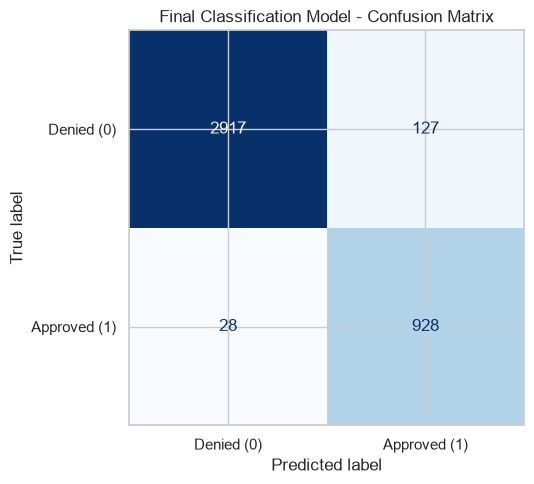

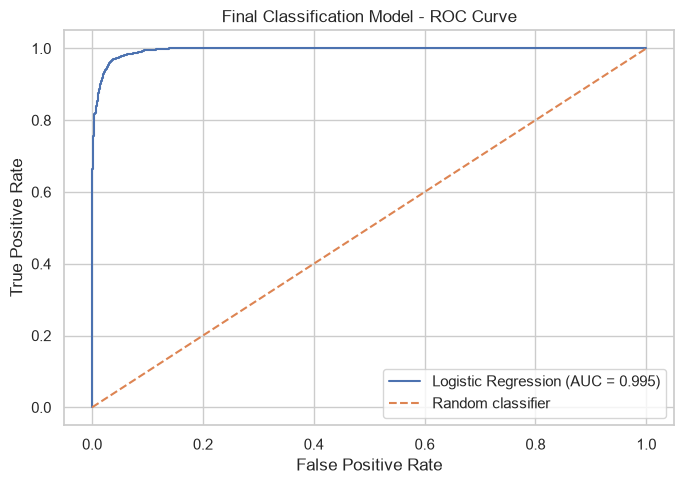

In [67]:
# Confusion Matrix
cm = confusion_matrix(y_class_test, class_test_pred)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Denied (0)", "Approved (1)"]
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title("Final Classification Model - Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_class_test, class_test_proba)
roc_auc = roc_auc_score(y_class_test, class_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Classification Model - ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 5.3 Business Error Cost on the Test Set

Because approving a potentially bad loan has a higher estimated cost than rejecting a potentially good loan, the final model is also evaluated using the project's predefined business cost function.


In [68]:
test_business_cost = business_error_cost(
    y_class_test,
    class_test_pred
)

test_business_cost_df = pd.DataFrame({
    "Measure": [
        "False Positives",
        "False Negatives",
        "False Positive Cost ($)",
        "False Negative Cost ($)",
        "Total Error Cost ($)",
        "Cost per Application ($)"
    ],
    "Value": [
        test_business_cost["false_positives"],
        test_business_cost["false_negatives"],
        test_business_cost["false_positive_cost"],
        test_business_cost["false_negative_cost"],
        test_business_cost["total_cost"],
        test_business_cost["total_cost"] / len(y_class_test)
    ]
})

display(test_business_cost_df)


,Measure,Value
0,False Positives,127.000
1,False Negatives,28.000
2,False Positive Cost ($),"6,350,000.000"
3,False Negative Cost ($),"224,000.000"
4,Total Error Cost ($),"6,574,000.000"
5,Cost per Application ($),"1,643.500"


## 5.4 Regression Performance: Predicted vs Actual

The regression model predicts the continuous `RiskScore`. A predicted-versus-actual scatter plot is used to assess how closely predictions follow the observed values.

Points close to the diagonal represent accurate predictions. Systematic deviations from the diagonal can indicate bias or areas where the model struggles.


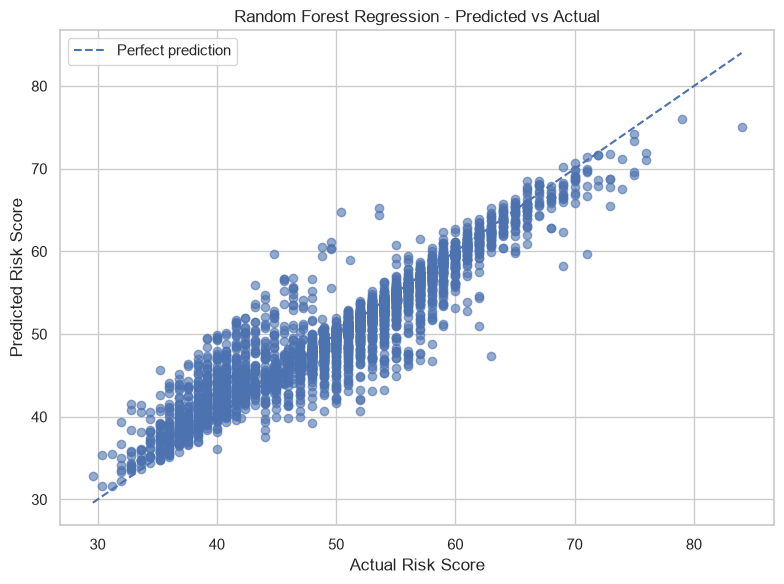

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, reg_test_pred, alpha=0.6)

min_value = min(y_reg_test.min(), reg_test_pred.min())
max_value = max(y_reg_test.max(), reg_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Random Forest Regression - Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()


## 5.5 Performance Across Applicant Segments

Overall test metrics can hide differences between groups. The following analysis evaluates classification performance across selected business-relevant segments available in the dataset.

For categorical segments, we report:
- Number of applications
- Accuracy
- Precision
- Recall
- F1-score

Small groups should be interpreted cautiously because their metrics can be unstable.


In [70]:
def segment_classification_performance(X_segment, y_true, y_pred, segment_name):
    results = []

    for group in X_segment[segment_name].dropna().unique():
        mask = X_segment[segment_name].eq(group)
        n = mask.sum()

        if n == 0:
            continue

        results.append({
            "Segment": group,
            "N": n,
            "Accuracy": accuracy_score(y_true[mask], y_pred[mask]),
            "Precision": precision_score(
                y_true[mask], y_pred[mask], zero_division=0
            ),
            "Recall": recall_score(
                y_true[mask], y_pred[mask], zero_division=0
            ),
            "F1": f1_score(
                y_true[mask], y_pred[mask], zero_division=0
            )
        })

    return pd.DataFrame(results).sort_values("N", ascending=False)

segment_results = {}

for segment in ["EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus", "LoanPurpose", "EducationLevel"]:
    if segment in X_test.columns:
        segment_results[segment] = segment_classification_performance(
            X_test.reset_index(drop=True),
            y_class_test.reset_index(drop=True),
            pd.Series(class_test_pred),
            segment
        )

        print(f"Performance by {segment}")
        display(segment_results[segment])


Performance by EmploymentStatus


,Segment,N,Accuracy,Precision,Recall,F1
0,Employed,3402,0.962,0.885,0.971,0.926
2,Self-Employed,311,0.945,0.835,0.988,0.905
1,Unemployed,287,0.965,0.870,0.940,0.904


Performance by MaritalStatus


,Segment,N,Accuracy,Precision,Recall,F1
0,Married,1911,0.964,0.884,0.975,0.928
1,Single,1152,0.959,0.878,0.964,0.919
2,Divorced,506,0.951,0.846,0.957,0.898
3,Widowed,164,0.945,0.830,0.975,0.897


Performance by HomeOwnershipStatus


,Segment,N,Accuracy,Precision,Recall,F1
0,Mortgage,1624,0.958,0.872,0.973,0.919
3,Rent,1175,0.970,0.896,0.985,0.938
2,Own,786,0.963,0.920,0.942,0.931
1,Other,415,0.947,0.772,0.986,0.866


Performance by LoanPurpose


,Segment,N,Accuracy,Precision,Recall,F1
3,Home,1196,0.966,0.896,0.977,0.935
1,Debt Consolidation,1030,0.954,0.842,0.978,0.905
2,Auto,773,0.970,0.915,0.968,0.941
0,Education,590,0.959,0.890,0.960,0.924
4,Other,411,0.951,0.842,0.955,0.895


Performance by EducationLevel


,Segment,N,Accuracy,Precision,Recall,F1
2,Bachelor,1163,0.963,0.905,0.969,0.936
1,High School,1086,0.975,0.880,0.970,0.923
0,Associate,782,0.964,0.876,0.963,0.918
4,Master,620,0.942,0.884,0.974,0.927
3,Doctorate,156,0.929,0.872,0.986,0.925


## 5.6 Identify Potential Biases and Limitations

Segment-level evaluation is not evidence that the model is fair or unfair by itself. It is a diagnostic step that can identify groups where performance differs enough to warrant further investigation.

Potential limitations include:

- Some demographic groups may contain relatively few observations.
- Performance metrics can be unstable for small subgroups.
- Historical lending decisions may contain institutional or process-related biases that a model can learn.
- Correlation between applicant characteristics and protected or sensitive attributes does not establish causation.
- A high overall ROC-AUC does not guarantee equal error rates across every group.
- The model should not be deployed as the sole basis for high-impact lending decisions without appropriate human oversight, validation, monitoring and governance.


## 5.7 Classification Feature Importance / Significance

Logistic Regression provides signed coefficients that indicate how each transformed feature is associated with the model's predicted class, holding the other model inputs constant.

Because categorical variables were one-hot encoded, the interpretation is performed on the **transformed feature names** rather than only the original column names.

Large absolute coefficients indicate stronger model influence; the sign indicates the direction of association with the positive class.


Top 20 classification features by absolute coefficient:


,Feature,Coefficient,Absolute_Importance
0,num__TotalDebtToIncomeRatio,-11.064,11.064
1,cat__BankruptcyHistory_1,-7.124,7.124
2,num__InterestRate,-6.252,6.252
3,num__MonthlyIncome,5.615,5.615
4,cat__EmploymentStatus_Unemployed,-4.694,4.694
5,num__NetWorth,3.577,3.577
6,num__LengthOfCreditHistory,3.203,3.203
7,num__LoanAmount,-2.885,2.885
8,num__CreditScore,-2.535,2.535
9,cat__HomeOwnershipStatus_Rent,-2.295,2.295


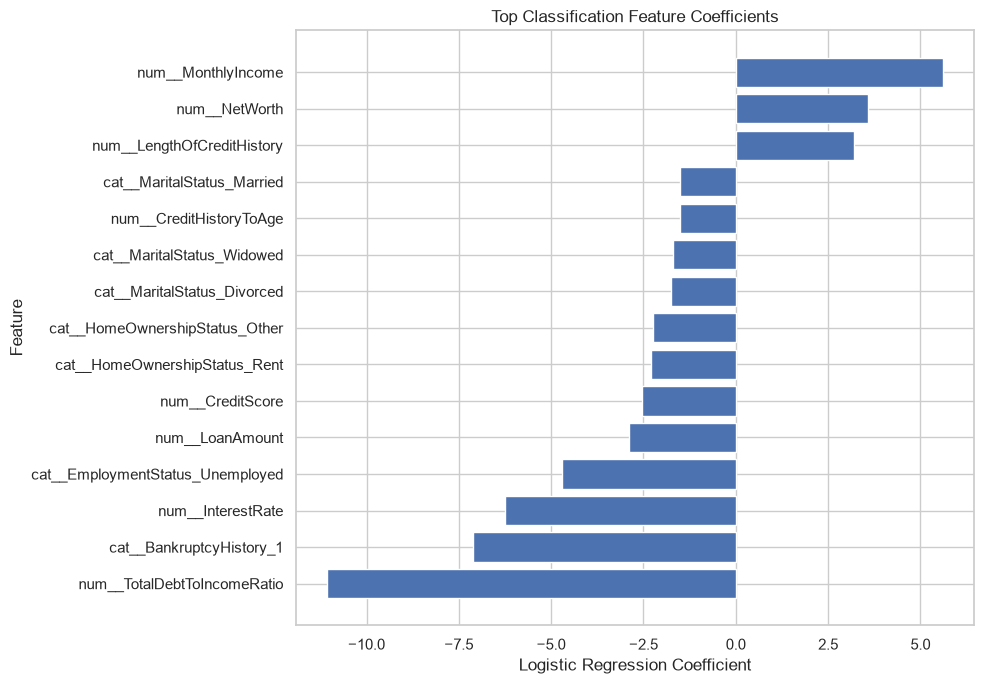

In [71]:
# Extract transformed feature names and logistic regression coefficients
classification_preprocessor = best_classification_model.named_steps["preprocessor"]
classification_model = best_classification_model.named_steps["model"]

feature_names_class = classification_preprocessor.get_feature_names_out()
classification_coefficients = classification_model.coef_[0]

classification_importance = pd.DataFrame({
    "Feature": feature_names_class,
    "Coefficient": classification_coefficients,
    "Absolute_Importance": np.abs(classification_coefficients)
}).sort_values(
    "Absolute_Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 classification features by absolute coefficient:")
display(classification_importance.head(20))

plt.figure(figsize=(10, 7))
top_class_features = classification_importance.head(15).sort_values("Coefficient")

plt.barh(
    top_class_features["Feature"],
    top_class_features["Coefficient"]
)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Classification Feature Coefficients")
plt.tight_layout()
plt.show()


## 5.8 Regression Feature Importance

Random Forest provides feature-importance values based on the contribution of transformed features to impurity reduction across the ensemble.

These values indicate which features the model relied on most strongly for predicting `RiskScore`. They should be interpreted as model importance rather than causal effects.


Top 20 regression features:


,Feature,Importance
0,num__DebtToIncomeRatio,0.119
1,num__MonthlyIncome,0.113
2,num__TotalDebtToIncomeRatio,0.109
3,num__NetWorth,0.103
4,cat__BankruptcyHistory_1,0.073
5,cat__BankruptcyHistory_0,0.072
6,num__PreviousLoanDefaults,0.063
7,num__InterestRate,0.061
8,num__AnnualIncome,0.054
9,num__LoanToIncome,0.045


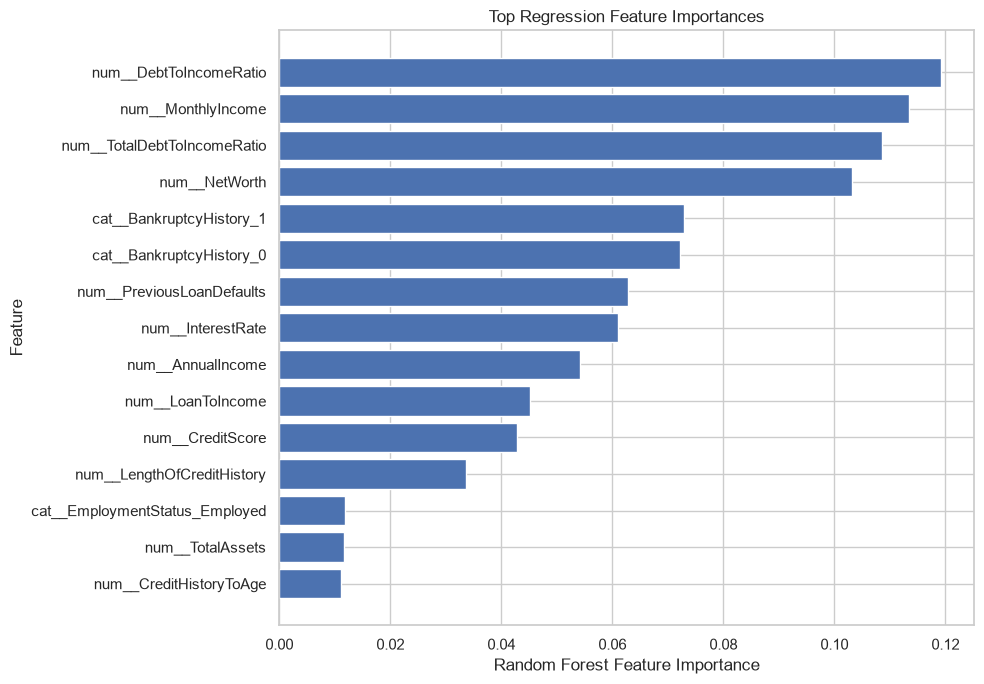

In [72]:
regression_preprocessor = best_regression_model.named_steps["preprocessor"]
regression_model = best_regression_model.named_steps["model"]

feature_names_reg = regression_preprocessor.get_feature_names_out()
regression_importances = regression_model.feature_importances_

regression_importance = pd.DataFrame({
    "Feature": feature_names_reg,
    "Importance": regression_importances
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 regression features:")
display(regression_importance.head(20))

plt.figure(figsize=(10, 7))
top_reg_features = regression_importance.head(15).sort_values("Importance")

plt.barh(
    top_reg_features["Feature"],
    top_reg_features["Importance"]
)
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top Regression Feature Importances")
plt.tight_layout()
plt.show()


## 5.9 Business Recommendations

The model findings should be translated into actions rather than treated as an automated decision by themselves.

### Recommendation 1 — Use the classification model as a decision-support tool
Use the predicted approval probability to prioritize applications for review. Applications near the operational decision threshold can receive additional human assessment.

### Recommendation 2 — Focus risk controls on influential financial variables
The highest-impact features identified by the model should guide further investigation into affordability, debt exposure, credit history and repayment capacity.

### Recommendation 3 — Monitor false-positive and false-negative costs
Because the estimated cost of a false positive is substantially higher than that of a false negative, model monitoring should track both the number and financial cost of each error type.

### Recommendation 4 — Monitor performance across applicant segments
Track accuracy, precision, recall and error rates across meaningful segments over time. Material differences should trigger investigation rather than being ignored by the overall accuracy figure.

### Recommendation 5 — Keep human oversight for high-impact decisions
The model should support qualified loan officers and risk teams rather than automatically replacing governance, policy checks or regulatory review.


## 5.10 Potential Improvements

Future versions of the solution could improve the analysis by:

1. Performing probability-threshold optimization using explicit business costs.
2. Calibrating predicted approval probabilities.
3. Testing additional algorithms such as Gradient Boosting, XGBoost or HistGradientBoosting.
4. Using repeated cross-validation to obtain more stable performance estimates.
5. Conducting formal fairness analysis across relevant demographic groups.
6. Adding explainability methods such as permutation importance and SHAP where appropriate.
7. Monitoring model drift after deployment.
8. Validating the model on a genuinely later time period to test temporal generalization.
9. Reviewing potentially sensitive or proxy variables with compliance and governance teams.
10. Establishing a model-monitoring framework covering accuracy, calibration, error costs, segment performance and data drift.


# Executive Summary for Business Stakeholders

The project developed two complementary machine-learning models for FinTech Innovations:

- **Logistic Regression** predicts whether a loan application will be approved.
- **Random Forest Regression** predicts the continuous `RiskScore`.

The final models were selected through five-fold cross-validation and GridSearchCV using only the training data. The final test-set evaluation provides an independent estimate of how the models perform on unseen applications.

The classification model should be assessed using both statistical performance and the financial consequences of false positives and false negatives. The regression model should be assessed using MAE, RMSE and R².

Feature-importance analysis provides a data-driven view of which applicant characteristics the models rely on most. These findings should inform further risk analysis, but feature importance should not be interpreted as proof that a variable causes loan approval or risk.

Overall, the recommended implementation is a **human-in-the-loop decision-support system** with continuous monitoring of predictive performance, business error costs, segment-level performance, fairness indicators and data drift.


# Final Conclusion

The modeling lifecycle is now complete:

**Business Understanding → Data Understanding → Data Preparation → Modeling → Hyperparameter Tuning → Test Evaluation → Interpretation → Business Recommendations**

The final evaluation should be considered the primary evidence for model performance because the test set was not used during model selection.

The solution is ready for further validation and controlled implementation, subject to business, compliance, fairness and operational review.
